In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import ee
import geemap

In [2]:
ee.Authenticate()
ee.Initialize(project="paolomizu")

from functions import extract_timeseries_to_region

In [5]:
# Define the full Hanaano region box
hanaano_box = ee.Geometry.Polygon([
    [40,3],
    [42.5,3],
    [42.5,5],
    [40,5],
    [40,3]
])

def fc_from_geojson(path):
    with open(path, "r") as f:
        geojson = json.load(f)
    return ee.FeatureCollection(geojson)

aoi = fc_from_geojson("../geojson/alenolie_irrigation_scheme.geojson")
control = fc_from_geojson("../geojson/control_field.geojson")
buffer = fc_from_geojson("../geojson/buffer.geojson")

# # Define a FeatureCollection object from the json object of the irrigation scheme
# with open("../geojson/alenolie_irrigation_scheme.geojson", "r") as f:
#     aoi_gjson = json.load(f)

# aoi = ee.FeatureCollection(aoi_gjson)

# # Define a FeatureCollection object from the json object of the control field
# with open("../geojson/control_field.geojson", "r") as f:
#     control_gjson = json.load(f)

# control = ee.FeatureCollection(control_gjson)

# # Define a FeatureCollection object from the json object of the buffer zone
# with open("../geojson/buffer.geojson", "r") as f:
#     buffer_gjson = json.load(f)

# buffer = ee.FeatureCollection(buffer_gjson)

In [22]:
START = "2022-01-01"
END = "2026-04-30"
INTERVENTION_DATE = "2024-10-01"
BASELINE_START = "2018-01-01"
BASELINE_END = "2023-12-31"

In [11]:
def build_s2_ndvi_collection(
        geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
        start_date: str,
        end_date: str,
        cloud_threshold: int = 20
) -> ee.ImageCollection:
    """
    Return a cloud-masked Sentinel-2 SR collection with an NDVI band,
    filtered to the given geometry and date range.

    Args:
        geometry: area of interest
        start_date: ISO string, e.g. "2022-01-01"
        end_date: ISO string, e.g. "2026-12-31"
        cloud_threshold: max CLOUDY_PIXEL_PERCENTAGE to keep (default 20)
    
    Returns:
        ee.ImageCollection with bands (original + NDVI)
    """
    def mask_clouds(image: ee.Image) -> ee.Image:
        qa = image.select("QA60")
        cloud_mask = (
            qa.bitwiseAnd(1 << 10).eq(0)   # opaque clouds
              .And(qa.bitwiseAnd(1 << 11).eq(0))  # cirrus
        )
        # Also mask cloud shadows via SCL band (S2 SR only)
        scl = image.select("SCL")
        shadow_mask = scl.neq(3)  # SCL class 3 = cloud shadow

        return (
            image
            .updateMask(cloud_mask.And(shadow_mask))
            .divide(10000)  # scale reflectance to [0, 1]
            .copyProperties(image, ["system:time_start"])
        )
    
    def add_ndvi(image: ee.Image) -> ee.Image:
        ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        return image.addBands(ndvi)

    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_clouds)
        .map(add_ndvi)
    )
    

In [15]:
# Monthly NDVI aggregation
def monthly_ndvi(
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    start_date: str,
    end_date: str,
    cloud_threshold: int = 20,
    reducer: str = "median",   # "median" | "mean"
) -> ee.ImageCollection:
    """
    Compute monthly NDVI composites (median or mean) for a given geometry.

    Each output image carries:
      - a single 'NDVI' band (the monthly composite)
      - 'year', 'month', 'system:time_start' properties for easy charting

    Args:
        geometry:        the zone of interest.
        start_date:      Start of analysis period (ISO string).
        end_date:        End of analysis period (ISO string).
        cloud_threshold: Passed through to build_s2_ndvi_collection.
        reducer:         "median" (default, recommended) or "mean".

    Returns:
        ee.ImageCollection of monthly NDVI images.
    """

    collection = build_s2_ndvi_collection(
        geometry, start_date, end_date, cloud_threshold
    ).select("NDVI")

    _reducer = ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()

    # Build a list of (year, month) pairs spanning the period
    start = ee.Date(start_date)
    end   = ee.Date(end_date)
    n_months = end.difference(start, "month").round()
    month_offsets = ee.List.sequence(0, n_months.subtract(1))

    def composite_one_month(offset):
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")

        monthly = collection.filterDate(month_start, month_end)

        # Guard: if no images, return a masked constant image so the
        # collection stays dense but the value is null when extracted
        empty = ee.Image.constant(ee.Number(0)).selfMask().rename("NDVI")

        composite = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(_reducer).rename("NDVI"),
            empty,
        )

        return (
            ee.Image(composite)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())   # useful for QC later
        )

    return ee.ImageCollection(month_offsets.map(composite_one_month))

In [17]:
# Extract the time series to a pandas df
def ndvi_timeseries_to_df(
    monthly_collection: ee.ImageCollection,
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    scale: int = 10,            # S2 native resolution for visible and NIR bands
    zone_label: str = "zone",
) -> pd.DataFrame:
    """
    Reduce a monthly NDVI ImageCollection to a mean-per-zone time series
    and return a tidy pandas DataFrame.

    Args:
        monthly_collection: Output of monthly_ndvi().
        geometry:           The zone geometry to reduce over.
        scale:              Spatial scale in metres for the reduceRegion (default 20).
        zone_label:         String label added as a 'zone' column (e.g. 'aoi', 'control').

    Returns:
        pd.DataFrame with columns: date, ndvi, zone
    """

    def extract(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),   # mean of the monthly composite pixels
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        )
        return ee.Feature(None, {
            "date":     image.get("date_label"),
            "ndvi":     stats.get("NDVI"),       # will be None for empty months
            "n_images": image.get("n_images"),   # lets you flag sparse months in df
            "zone":     zone_label,
        })

    features = monthly_collection.map(extract)
    fc = ee.FeatureCollection(features)

    rows = fc.getInfo()["features"]
    records = [f["properties"] for f in rows]
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    return df

In [23]:
aoi_monthly_col = monthly_ndvi(
    geometry=aoi,
    start_date=START,
    end_date=END
)
df_aoi = ndvi_timeseries_to_df(aoi_monthly_col, aoi, zone_label="aoi")

In [25]:
control_monthly_col = monthly_ndvi(
    geometry=control,
    start_date=START,
    end_date=END
)
df_control = ndvi_timeseries_to_df(control_monthly_col, control, zone_label="control")

In [26]:
buffer_monthly_col = monthly_ndvi(
    geometry=buffer,
    start_date=START,
    end_date=END
)
df_buffer = ndvi_timeseries_to_df(buffer_monthly_col, buffer, zone_label="buffer")

In [27]:
df = pd.concat([df_aoi, df_buffer, df_control], ignore_index=True)

In [30]:
df.head()

,date,n_images,ndvi,zone
0,2022-01-01,5,0.184443,aoi
1,2022-02-01,4,0.137031,aoi
2,2022-03-01,6,0.145824,aoi
3,2022-04-01,2,0.157101,aoi
4,2022-05-01,1,0.296057,aoi


In [42]:
df["date"] = pd.to_datetime(df.date)

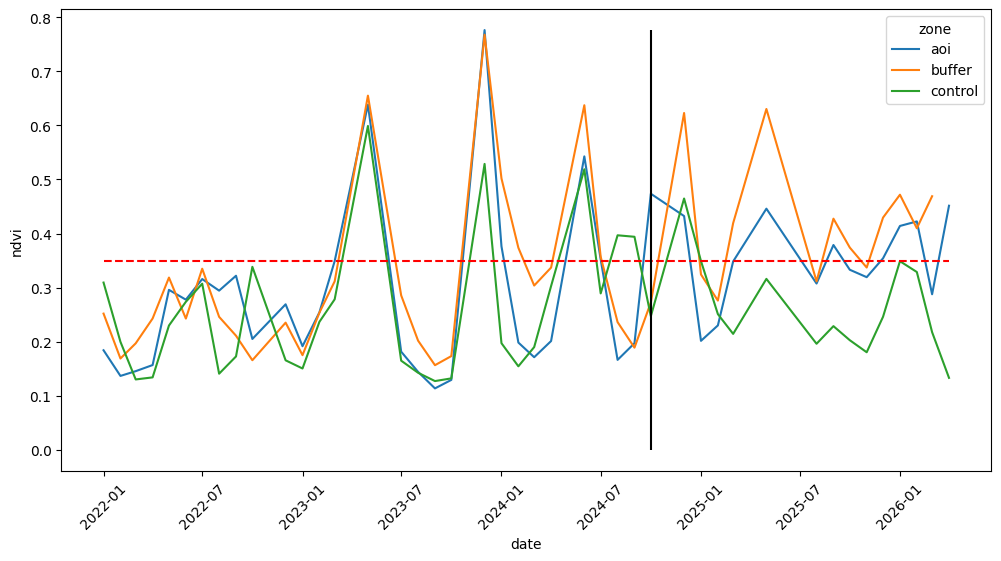

In [ ]:
from datetime import date

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="date",
    y="ndvi",
    hue="zone"
)
plt.hlines(
    y=0.35,
    xmin=min(df.date),
    xmax=max(df.date),
    linestyles="--",
    colors="red",
    label="Active Vegetation Threshold"
)

plt.vlines(
    x=date(2024,10,1),
    ymin=0,
    ymax=max(df.ndvi),
    linestyles="solid",
    colors="black",
    label="Intervention date"
)

plt.xticks(rotation=45)
plt.show()

In [55]:
def compute_monthly_baseline(
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    baseline_start: str,
    baseline_end: str,
    cloud_threshold: int = 20,
    scale: int = 10,
    zone_label: str = "zone",
) -> pd.DataFrame:
    """
    Compute per-calendar-month NDVI statistics over a baseline period.

    For each calendar month (1–12) computes: mean, median, std, min, max
    across all years in the baseline. Returns a tidy DataFrame that can be
    joined to the study-period time series to derive anomalies.

    Args:
        geometry:        Zone geometry (aoi, control, buffer).
        baseline_start:  Start of baseline period (ISO string).
        baseline_end:    End of baseline period (ISO string).
        cloud_threshold: Max cloud cover % for S2 filtering.
        scale:           reduceRegion scale in metres.
        zone_label:      Label added as 'zone' column.

    Returns:
        pd.DataFrame with columns:
            month, mean, median, std, min, max, n_images, zone
    """

    collection = build_s2_ndvi_collection(
        geometry, baseline_start, baseline_end, cloud_threshold
    ).select("NDVI")

    # Iterate over calendar months 1–12
    # For each, pool ALL images from that month across all baseline years
    # and reduce to scalar stats over the geometry
    months = ee.List.sequence(1, 12)

    def stats_for_month(month):
        month = ee.Number(month)

        monthly_images = collection.filter(
            ee.Filter.calendarRange(month, month, "month")
        )

        # Mosaic all same-month images across years into a single collection
        # then reduce to per-pixel stats — we want the distribution of
        # NDVI values across time, not a spatial mean first
        stats = monthly_images.reduce(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(),  sharedInputs=True)
            .combine(ee.Reducer.stdDev(),  sharedInputs=True)
            .combine(ee.Reducer.min(),     sharedInputs=True)
            .combine(ee.Reducer.max(),     sharedInputs=True)
            .combine(ee.Reducer.count(),   sharedInputs=True)
        ).reduceRegion(
            reducer=ee.Reducer.mean(),   # spatial mean of each stat band
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        )

        return ee.Feature(None, {
            "month":    month,
            "mean":     stats.get("NDVI_mean"),
            "median":   stats.get("NDVI_median"),
            "std":      stats.get("NDVI_stdDev"),
            "min":      stats.get("NDVI_min"),
            "max":      stats.get("NDVI_max"),
            "n_images": stats.get("NDVI_count"),
            "zone":     zone_label,
        })

    fc = ee.FeatureCollection(
        ee.List(months.map(stats_for_month))
    )

    rows = fc.getInfo()["features"]
    df = pd.DataFrame([f["properties"] for f in rows])
    df["month"] = df["month"].astype(int)
    df = df.sort_values("month").reset_index(drop=True)
    return df


def compute_anomalies(
    study_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Join study-period NDVI time series with baseline stats and compute
    anomalies. Expects both DataFrames to have a 'zone' column so the
    join is zone-aware.

    Adds columns:
        anomaly_abs   — NDVI minus baseline mean (absolute anomaly)
        anomaly_pct   — anomaly_abs as % of baseline mean
        z_score       — anomaly_abs divided by baseline std

    Args:
        study_df:    Output of ndvi_timeseries_to_df() — must have
                     columns: date, ndvi, zone.
        baseline_df: Output of compute_monthly_baseline() — must have
                     columns: month, mean, std, zone.

    Returns:
        study_df enriched with baseline stats and anomaly columns.
    """

    df = study_df.copy()
    df["month"] = df["date"].dt.month

    df = df.merge(
        baseline_df[["month", "mean", "median", "std", "min", "max", "zone"]],
        on=["month", "zone"],
        how="left",
    )

    df["anomaly_abs"] = df["ndvi"] - df["mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["std"]

    return df.drop(columns="month")  # month was a join key, date is sufficient

In [56]:
baseline_aoi = compute_monthly_baseline(aoi, BASELINE_START, BASELINE_END, zone_label="aoi")
baseline_buffer = compute_monthly_baseline(buffer, BASELINE_START, BASELINE_END, zone_label="buffer")
baseline_control = compute_monthly_baseline(control, BASELINE_START, BASELINE_END, zone_label="control")

baseline_df = pd.concat([baseline_aoi, baseline_buffer, baseline_control], ignore_index=True)

In [64]:
df_anomalies = compute_anomalies(df, baseline_df)
df_anomalies["date"] = pd.to_datetime(df_anomalies.date)

In [65]:
df_anomalies

,date,n_images,ndvi,zone,mean,median,std,min,max,anomaly_abs,anomaly_pct,z_score
0,2022-01-01,5,0.184443,aoi,0.209455,0.169192,0.097044,0.121907,0.482679,-0.025012,-11.941513,-0.257739
1,2022-02-01,4,0.137031,aoi,0.179685,0.150374,0.079412,0.076891,0.364583,-0.042654,-23.738354,-0.537123
2,2022-03-01,6,0.145824,aoi,0.196629,0.149983,0.115453,0.096909,0.571498,-0.050805,-25.837899,-0.440047
3,2022-04-01,2,0.157101,aoi,0.150646,0.127073,0.068289,0.079116,0.281597,0.006456,4.285372,0.094535
4,2022-05-01,1,0.296057,aoi,0.420280,0.416422,0.187137,0.149494,0.690240,-0.124223,-29.557250,-0.663809
...,...,...,...,...,...,...,...,...,...,...,...,...
151,2025-12-01,6,0.246327,control,0.359343,0.284102,0.223860,0.097188,0.828869,-0.113016,-31.450737,-0.504851
152,2026-01-01,8,0.349004,control,0.223117,0.183277,0.110050,0.112276,0.497853,0.125887,56.422062,1.143905
153,2026-02-01,5,0.329002,control,0.185515,0.150834,0.092170,0.079347,0.405075,0.143487,77.345165,1.556767
154,2026-03-01,2,0.217845,control,0.179110,0.142556,0.088528,0.091407,0.426480,0.038734,21.625953,0.437538


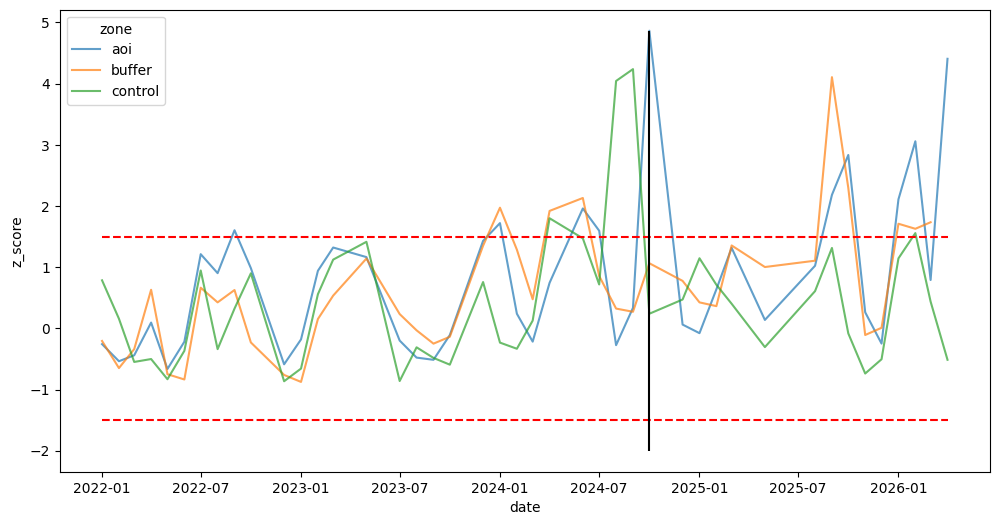

In [68]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_anomalies,
    x="date",
    y="z_score",
    hue="zone",
    alpha=0.7
)
plt.hlines(
    y=1.5,
    xmin=min(df_anomalies.date),
    xmax=max(df_anomalies.date),
    linestyles="--",
    colors="red"
)
plt.hlines(
    y=-1.5,
    xmin=min(df_anomalies.date),
    xmax=max(df_anomalies.date),
    linestyles="--",
    colors="red"
)

plt.vlines(
    x=date(2024,10,1),
    ymin=-2,
    ymax=max(df_anomalies.z_score),
    linestyles="solid",
    colors="black",
    label="Intervention date"
)

plt.xticks(rotation=45, minor=True)
plt.show()

In [86]:
# import ee
# import geemap
# import pandas as pd
# import json
from typing import Literal

# ee.Authenticate()
# ee.Initialize(project="paolomizu")

# ── Dates definition ────────────────────────────────────────────────────────
START = "2022-01-01"
END = "2026-04-30"
INTERVENTION_DATE = "2024-10-01"
START_BASELINE = "2018-01-01"
END_BASELINE = "2023-12-31"

# ── Regions definition ────────────────────────────────────────────────────────
# Define the full Hanaano region box
hanaano_box = ee.Geometry.Polygon([
    [40,3],
    [42.5,3],
    [42.5,5],
    [40,5],
    [40,3]
])

def fc_from_geojson(path):
    with open(path, "r") as f:
        geojson = json.load(f)
    return ee.FeatureCollection(geojson)

aoi = fc_from_geojson("../geojson/alenolie_irrigation_scheme.geojson")
control = fc_from_geojson("../geojson/control_field.geojson")
buffer = fc_from_geojson("../geojson/buffer.geojson")

# ── Seasons definition ────────────────────────────────────────────────────────

SEASONS = {
    "gu":    {"months": [3, 4, 5],       "label": "Gu (Long Rains, MAM)"},
    "deyr":  {"months": [10, 11, 12],    "label": "Deyr (Short Rains, OND)"},
    "dry1":  {"months": [6, 7, 8, 9],   "label": "Dry Season 1 (JJAS)"},
    "dry2":  {"months": [1, 2],          "label": "Dry Season 2 (JF)"},
}

# NDVI map visualisation params — reuse across all map calls
NDVI_VIZ = {
    "min": 0.0, "max": 0.8,
    "palette": ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"],
}
ANOMALY_VIZ = {
    "min": -0.3, "max": 0.3,
    "palette": ["#d73027", "#fc8d59", "#ffffbf", "#91cf60", "#1a9850"],
}


# ── 1. S2 collection builder ─────────────────────────────────────

def build_s2_ndvi_collection(
    geometry: ee.Geometry,
    start_date: str,
    end_date: str,
    cloud_threshold: int = 20,
) -> ee.ImageCollection:

    def mask_clouds(image):
        qa  = image.select("QA60")
        scl = image.select("SCL")
        cloud_mask  = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        shadow_mask = scl.neq(3)
        return (
            image.updateMask(cloud_mask.And(shadow_mask))
            .divide(10000)
            .copyProperties(image, ["system:time_start"])
        )

    def add_ndvi(image):
        return image.addBands(
            image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        )

    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_clouds)
        .map(add_ndvi)
        .select("NDVI")
    )


# ── 2. Monthly composites — returns ImageCollection AND/OR DataFrame ──────────

def monthly_ndvi(
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    start_date: str = START,
    end_date: str = END,
    cloud_threshold: int = 20,
    reducer: Literal["median", "mean"] = "median",
    return_images: bool = False,
    scale: int = 20,
    zone_label: str = "zone",
) -> dict:
    """
    Compute monthly NDVI composites.

    Returns a dict with keys:
        'collection'  — ee.ImageCollection of monthly composites (always)
        'dataframe'   — pd.DataFrame time series (always)

    Each image in the collection has properties:
        year, month, date_label, n_images
    and a single 'NDVI' band.
    """

    collection = build_s2_ndvi_collection(geometry, start_date, end_date, cloud_threshold)
    _reducer   = ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()

    start    = ee.Date(start_date)
    end      = ee.Date(end_date)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def composite_one_month(offset):
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = collection.filterDate(month_start, month_end)
        empty       = ee.Image.constant(ee.Number(0)).selfMask().rename("NDVI")

        composite = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(_reducer).rename("NDVI"),
            empty,
        )
        return (
            ee.Image(composite)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(composite_one_month))

    # ── DataFrame extraction
    def extract(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        )
        return ee.Feature(None, {
            "date":     image.get("date_label"),
            "ndvi":     stats.get("NDVI"),
            "n_images": image.get("n_images"),
            "zone":     zone_label,
        })

    rows = ee.FeatureCollection(monthly_col.map(extract)).getInfo()["features"]
    df   = pd.DataFrame([f["properties"] for f in rows])
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


# ── 3. Seasonal composites ────────────────────────────────────────────────────

def seasonal_ndvi(
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    start_year: int = int(START.split("-")[0]),
    end_year: int = int(END.split("-")[0]),
    cloud_threshold: int = 20,
    reducer: Literal["median", "mean"] = "median",
    seasons: dict = SEASONS,
    scale: int = 20,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-season NDVI composites for each year in the study period.

    Returns a dict with keys:
        'collection'  — ee.ImageCollection, one image per (year, season)
        'dataframe'   — pd.DataFrame with columns: year, season, ndvi, zone

    Each image in the collection has properties:
        year, season, season_label, system:time_start
    and a single 'NDVI' band.
    """

    _reducer = ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()
    years    = list(range(start_year, end_year + 1))
    images   = []

    for year in years:
        for season_key, season_info in seasons.items():
            months  = season_info["months"]
            # Handle Deyr wrapping: OND of year Y is Oct-Dec of year Y
            # Dry2 wrapping: JF of year Y is Jan-Feb of year Y
            # No wrapping needed for this region's seasons as defined
            s_start = ee.Date.fromYMD(year, months[0],  1)
            s_end   = ee.Date.fromYMD(year, months[-1], 1).advance(1, "month")

            col = build_s2_ndvi_collection(
                geometry,
                f"{year}-{months[0]:02d}-01",
                f"{year}-{months[-1]:02d}-28",  # approximate — GEE clips to real days
                cloud_threshold,
            )

            empty     = ee.Image.constant(ee.Number(0)).selfMask().rename("NDVI")
            composite = ee.Algorithms.If(
                col.size().gt(0),
                col.reduce(_reducer).rename("NDVI"),
                empty,
            )

            image = (
                ee.Image(composite)
                .set("year",              year)
                .set("season",            season_key)
                .set("season_label",      season_info["label"])
                .set("system:time_start", s_start.millis())
                .set("n_images",          col.size())
            )
            images.append(image)

    seasonal_col = ee.ImageCollection(images)

    # ── DataFrame extraction
    def extract(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        )
        return ee.Feature(None, {
            "year":         image.get("year"),
            "season":       image.get("season"),
            "season_label": image.get("season_label"),
            "ndvi":         stats.get("NDVI"),
            "n_images":     image.get("n_images"),
            "zone":         zone_label,
        })

    rows = ee.FeatureCollection(seasonal_col.map(extract)).getInfo()["features"]
    df   = pd.DataFrame([f["properties"] for f in rows])
    df   = df.sort_values(["year", "season"]).reset_index(drop=True)

    return {"collection": seasonal_col, "dataframe": df}


# ── 4. Baseline stats — returns DataFrame AND image per calendar month ────────

def compute_monthly_baseline(
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    baseline_start: str = START_BASELINE,
    baseline_end: str = END_BASELINE,
    cloud_threshold: int = 20,
    scale: int = 20,
    zone_label: str = "zone",
) -> dict:
    """
    Compute baseline NDVI statistics for each calendar month (1–12).

    Returns a dict with keys:
        'dataframe'     — pd.DataFrame with stats per calendar month
        'mean_images'   — ee.ImageCollection, one mean image per calendar month
                          (used for anomaly map computation)
    """

    collection = build_s2_ndvi_collection(
        geometry, baseline_start, baseline_end, cloud_threshold
    )
    months = ee.List.sequence(1, 12)

    def stats_for_month(month):
        month   = ee.Number(month)
        monthly = collection.filter(ee.Filter.calendarRange(month, month, "month"))
        empty   = ee.Image.constant(ee.Number(0)).selfMask().rename("NDVI")

        stats_image = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_images", monthly.size())
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    # Extract mean images as a separate collection for anomaly computation
    mean_images = baseline_col.map(
        lambda img: img.select("NDVI_mean").rename("NDVI").set("month", img.get("month"))
    )
    std_images = baseline_col.map(
        lambda img: img.select("NDVI_stdDev").rename("NDVI_std").set("month", img.get("month"))
    )

    # ── DataFrame
    def extract(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        )
        return ee.Feature(None, {
            "month":    image.get("month"),
            "mean":     stats.get("NDVI_mean"),
            "median":   stats.get("NDVI_median"),
            "std":      stats.get("NDVI_stdDev"),
            "min":      stats.get("NDVI_min"),
            "max":      stats.get("NDVI_max"),
            "n_images": image.get("n_images"),
            "zone":     zone_label,
        })

    rows = ee.FeatureCollection(baseline_col.map(extract)).getInfo()["features"]
    df   = pd.DataFrame([f["properties"] for f in rows])
    df["month"] = df["month"].astype(int)

    return {
        "dataframe":   df.sort_values("month").reset_index(drop=True),
        "mean_images": mean_images,
        "std_images":  std_images,
    }


# ── 5. Anomaly images ─────────────────────────────────────────────────────────

def compute_anomaly_images(
    study_collection: ee.ImageCollection,   # monthly or seasonal
    baseline_mean_images: ee.ImageCollection,
    baseline_std_images: ee.ImageCollection,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> ee.ImageCollection:
    """
    For each image in the study collection, subtract the corresponding
    baseline mean image to produce anomaly and z-score images.

    For monthly: matches on 'month' property.
    For seasonal: matches on 'season' property, using mean across all
                  months in that season from the baseline.

    Returns an ee.ImageCollection where each image has bands:
        NDVI           — original NDVI
        anomaly_abs    — NDVI minus baseline mean
        z_score        — anomaly_abs divided by baseline std
    and all original properties preserved.
    """

    if temporal_resolution == "monthly":

        def add_anomaly_monthly(image):
            month = image.get("month")

            baseline_mean = ee.Image(
                baseline_mean_images
                .filter(ee.Filter.eq("month", month))
                .first()
            )
            baseline_std = ee.Image(
                baseline_std_images
                .filter(ee.Filter.eq("month", month))
                .first()
            )

            anomaly_abs = image.select("NDVI").subtract(baseline_mean).rename("anomaly_abs")
            z_score     = anomaly_abs.divide(baseline_std).rename("z_score")

            return (
                image
                .addBands(anomaly_abs)
                .addBands(z_score)
                .copyProperties(image)
            )

        return study_collection.map(add_anomaly_monthly)

    else:  # seasonal — average the relevant baseline months

        def add_anomaly_seasonal(image):
            season_key = image.get("season")

            # Retrieve month list for this season server-side via a lookup dict
            season_months_dict = ee.Dictionary({
                "gu":   [3, 4, 5],
                "deyr": [10, 11, 12],
                "dry1": [6, 7, 8, 9],
                "dry2": [1, 2],
            })
            month_list = ee.List(season_months_dict.get(season_key))

            seasonal_mean = (
                baseline_mean_images
                .filter(ee.Filter.inList("month", month_list))
                .mean()
            )
            seasonal_std = (
                baseline_std_images
                .filter(ee.Filter.inList("month", month_list))
                .mean()  # average std across season months — acceptable approximation
            )

            anomaly_abs = image.select("NDVI").subtract(seasonal_mean).rename("anomaly_abs")
            z_score     = anomaly_abs.divide(seasonal_std).rename("z_score")

            return (
                image
                .addBands(anomaly_abs)
                .addBands(z_score)
                .copyProperties(image)
            )

        return study_collection.map(add_anomaly_seasonal)


# ── 6. Anomaly DataFrame ──────────────────────────────────────────────────────

def compute_anomalies(
    study_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> pd.DataFrame:
    """
    Join study-period NDVI with baseline stats and compute anomalies.
    Handles both monthly (joins on month) and seasonal (joins on season
    months mapped from season key) resolutions.
    """

    # Map season keys to a representative month for the baseline join
    SEASON_TO_MONTHS = {
        "gu":   [3, 4, 5],
        "deyr": [10, 11, 12],
        "dry1": [6, 7, 8, 9],
        "dry2": [1, 2],
    }

    df = study_df.copy()

    if temporal_resolution == "monthly":
        df["month"] = df["date"].dt.month
        join_key = "month"

    else:
        # For each season, compute mean baseline stats across its months
        season_baseline_rows = []
        for season_key, months in SEASON_TO_MONTHS.items():
            subset = baseline_df[baseline_df["month"].isin(months)]
            # Group by zone so the join stays zone-aware
            for zone, grp in subset.groupby("zone"):
                season_baseline_rows.append({
                    "season": season_key,
                    "zone":   zone,
                    "mean":   grp["mean"].mean(),
                    "median": grp["median"].mean(),
                    "std":    grp["std"].mean(),
                    "min":    grp["min"].min(),
                    "max":    grp["max"].max(),
                })

        baseline_df = pd.DataFrame(season_baseline_rows)
        join_key = "season"

    df = df.merge(
        baseline_df[[join_key, "mean", "median", "std", "min", "max", "zone"]],
        on=[join_key, "zone"],
        how="left",
    )

    df["anomaly_abs"] = df["ndvi"] - df["mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["std"]

    # Clean up the temporary join key if it was added
    if temporal_resolution == "monthly" and "month" not in study_df.columns:
        df = df.drop(columns="month")

    return df


# ── 7. Map display helper ─────────────────────────────────────────────────────

def add_ndvi_layers_to_map(
    m: geemap.Map,
    collection: ee.ImageCollection,
    date_label: str,
    geometry: ee.Geometry | ee.Feature | ee.FeatureCollection,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> None:
    """
    Add NDVI, anomaly and z-score layers for a given date/season label
    to a geemap Map object.

    date_label format:
        monthly:  "YYYY-MM"        e.g. "2025-01"
        seasonal: "YYYY-seasonkey" e.g. "2025-dry1", "2025-deyr"
    """

    # Split on first hyphen only — protects against season keys that
    # could theoretically contain hyphens, and avoids int() on "dry1"
    year_str, period_str = date_label.split("-", maxsplit=1)
    year = int(year_str)

    if temporal_resolution == "monthly":
        image = ee.Image(
            collection
            .filter(ee.Filter.eq("year",  year))
            .filter(ee.Filter.eq("month", int(period_str)))  # "01" → 1, safe
            .first()
        )
    else:
        image = ee.Image(
            collection
            .filter(ee.Filter.eq("year",   year))
            .filter(ee.Filter.eq("season", period_str))  # "dry1" stays a string
            .first()
        )

    prefix = f"{label_prefix} " if label_prefix else ""

    m.addLayer(
        image.select("NDVI"),
        NDVI_VIZ,
        f"{prefix}NDVI {date_label}",
    )
    m.addLayer(
        image.select("anomaly_abs"),
        ANOMALY_VIZ,
        f"{prefix}Anomaly {date_label}",
    )
    m.addLayer(
        image.select("z_score"),
        {"min": -3, "max": 3, "palette": ["#d73027", "#ffffbf", "#1a9850"]},
        f"{prefix}Z-score {date_label}",
    )
    m.centerObject(geometry, zoom=13)


In [ ]:
# ── Build collections
result_aoi = monthly_ndvi(aoi, zone_label="aoi")
baseline   = compute_monthly_baseline(aoi, zone_label="aoi")

# ── Add anomaly bands to the monthly image collection
anomaly_col = compute_anomaly_images(
    study_collection=result_aoi["collection"],
    baseline_mean_images=baseline["mean_images"],
    baseline_std_images=baseline["std_images"],
    temporal_resolution="monthly",
)

# ── Seasonal version
seas_aoi = seasonal_ndvi(aoi, zone_label="aoi")
anomaly_seas_col = compute_anomaly_images(
    study_collection=seas_aoi["collection"],
    baseline_mean_images=baseline["mean_images"],
    baseline_std_images=baseline["std_images"],
    temporal_resolution="seasonal",
)

m = geemap.Map()
# add_ndvi_layers_to_map(m, anomaly_col, "2025-01", aoi, label_prefix="AOI")
add_ndvi_layers_to_map(m, anomaly_seas_col, "2025-dry2", aoi, label_prefix="AOI", temporal_resolution="seasonal")
m

In [32]:
import ee
import geemap
import pandas as pd
import json
from dataclasses import dataclass, field
from typing import Literal, Union
from pathlib import Path

ee.Authenticate()
ee.Initialize(project="paolomizu")


# ══════════════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class AnalysisConfig:
    """
    Central configuration for an NDVI analysis run.
    Separating config from logic makes the functions reusable across
    regions and time periods without touching function signatures.

    Args:
        study_start:        Start of study period (ISO string).
        study_end:          End of study period (ISO string).
        baseline_start:     Start of baseline period (ISO string).
        baseline_end:       End of baseline period (ISO string).
        intervention_date:  Date of intervention (ISO string). Used for
                            annotations on charts, not for filtering.
        cloud_threshold:    Max CLOUDY_PIXEL_PERCENTAGE for S2 filtering.
        scale:              Spatial scale in metres for reduceRegion.
        reducer:            "median" (default) or "mean" for compositing.
        seasons:            Dict of season definitions. Each entry:
                            {"months": [int, ...], "label": str}
        ndvi_viz:           GEE visualisation params for NDVI layers.
        anomaly_viz:        GEE visualisation params for anomaly layers.
        zscore_viz:         GEE visualisation params for z-score layers.
        export_crs:         CRS for GeoTIFF export (default EPSG:4326).
        export_scale:       Scale in metres for GeoTIFF export.
    """

    study_start:       str = "2022-01-01"
    study_end:         str = "2026-04-30"
    baseline_start:    str = "2018-01-01"
    baseline_end:      str = "2023-12-31"
    intervention_date: str = "2024-10-01"
    cloud_threshold:   int = 20
    scale:             int = 20
    reducer:           Literal["median", "mean"] = "median"

    seasons: dict = field(default_factory=lambda: {
        "dry1": {"months": [1, 2],       "label": "Dry Season 1 (JF)"},
        "gu":   {"months": [3, 4, 5],    "label": "Gu (Long Rains, MAM)"},
        "dry2": {"months": [6, 7, 8, 9], "label": "Dry Season 2 (JJAS)"},
        "deyr": {"months": [10, 11, 12], "label": "Deyr (Short Rains, OND)"},
    })

    ndvi_viz: dict = field(default_factory=lambda: {
        "min": 0.0, "max": 0.8,
        "palette": ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"],
    })
    anomaly_viz: dict = field(default_factory=lambda: {
        "min": -0.3, "max": 0.3,
        "palette": ["#d73027", "#fc8d59", "#ffffbf", "#91cf60", "#1a9850"],
    })
    zscore_viz: dict = field(default_factory=lambda: {
        "min": -3, "max": 3,
        "palette": ["#d73027", "#ffffbf", "#1a9850"],
    })

    export_crs:   str = "EPSG:4326"
    export_scale: int = 10   # 10m for export — finer than analysis scale


# ══════════════════════════════════════════════════════════════════════════════
# Geometry helpers
# ══════════════════════════════════════════════════════════════════════════════

# Type alias — used throughout
GEEGeometry = Union[ee.Geometry, ee.Feature, ee.FeatureCollection]


def fc_from_geojson(path: Union[str, Path]) -> ee.FeatureCollection:
    """Load a local GeoJSON file as an ee.FeatureCollection."""
    with open(path, "r") as f:
        geojson = json.load(f)
    return ee.FeatureCollection(geojson)


def to_geometry(region: GEEGeometry) -> ee.Geometry:
    """
    Normalise any GEE region type to ee.Geometry.
    Needed because filterBounds, reduceRegion, etc. behave differently
    depending on whether they receive a Geometry, Feature, or FeatureCollection.
    """
    if isinstance(region, ee.FeatureCollection):
        return region.geometry()
    if isinstance(region, ee.Feature):
        return region.geometry()
    return region


# ══════════════════════════════════════════════════════════════════════════════
# Core collection builder
# ══════════════════════════════════════════════════════════════════════════════

def build_s2_ndvi_collection(
    geometry: GEEGeometry,
    start_date: str,
    end_date: str,
    cloud_threshold: int = 20,
) -> ee.ImageCollection:
    """
    Return a cloud-masked, NDVI-only Sentinel-2 SR collection.
    This is the single entry point for raw data — all other functions
    filter down from here rather than rebuilding.
    """

    def mask_clouds(image: ee.Image) -> ee.Image:
        qa          = image.select("QA60")
        scl         = image.select("SCL")
        cloud_mask  = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        shadow_mask = scl.neq(3)
        return (
            image
            .updateMask(cloud_mask.And(shadow_mask))
            .divide(10000)
            .copyProperties(image, ["system:time_start"])
        )

    def add_ndvi(image: ee.Image) -> ee.Image:
        return image.addBands(
            image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        )

    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(to_geometry(geometry))
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_clouds)
        .map(add_ndvi)
        .select("NDVI")
    )


# ══════════════════════════════════════════════════════════════════════════════
# Internal helpers
# ══════════════════════════════════════════════════════════════════════════════

def _get_reducer(reducer: Literal["median", "mean"]) -> ee.Reducer:
    return ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()



def _collection_to_dataframe(
    collection: ee.ImageCollection,
    geometry: GEEGeometry,
    scale: int,
    properties: list[str],
    zone_label: str,
    band_names: list[str] = ["NDVI"],
) -> pd.DataFrame:
    """
    Reduce an ImageCollection to a scalar-per-image DataFrame.

    Args:
        band_names: List of bands to extract from reduceRegion
                    (e.g. ["NDVI"] or ["NDVI_mean", "NDVI_stdDev"])
    """
    geom = to_geometry(geometry)

    def extract(image: ee.Image) -> ee.Feature:
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=scale,
            maxPixels=1e9,
        )

        props = {p: image.get(p) for p in properties}
        for band in band_names:
            props[band] = stats.get(band)

        props["zone"] = zone_label
        return ee.Feature(None, props)

    rows = ee.FeatureCollection(collection.map(extract)).getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in rows])


def _safe_composite(
    collection: ee.ImageCollection,
    reducer: ee.Reducer,
) -> ee.Image:
    """
    Reduce a collection to a composite, returning a fully masked image
    if the collection is empty. Prevents band-not-found errors downstream.
    """
    empty = ee.Image.constant(0).selfMask().rename("NDVI")
    return ee.Image(
        ee.Algorithms.If(
            collection.size().gt(0),
            collection.reduce(reducer).rename("NDVI"),
            empty,
        )
    )


# ══════════════════════════════════════════════════════════════════════════════
# Monthly composites
# ══════════════════════════════════════════════════════════════════════════════

def monthly_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute monthly NDVI composites over the study period.

    Builds the full S2 collection once, then filters per month — avoids
    redundant collection instantiation for every time step.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per month, 'NDVI' band
          "dataframe":  pd.DataFrame,        # columns: date, ndvi, n_images, zone
        }
    """
    cfg = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    # Build once, filter per month
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    start    = ee.Date(cfg.study_start)
    end      = ee.Date(cfg.study_end)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def composite_one_month(offset: ee.Number) -> ee.Image:
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = full_col.filterDate(month_start, month_end)

        return (
            _safe_composite(monthly, _reducer)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(composite_one_month))

    df = _collection_to_dataframe(
        monthly_col, geometry, cfg.scale,
        properties=["date_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.rename(columns={"date_label": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Seasonal composites
# ══════════════════════════════════════════════════════════════════════════════

def seasonal_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-season NDVI composites for each year in the study period.

    Builds the full S2 collection once, then filters per season/year.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per (year, season)
          "dataframe":  pd.DataFrame,        # columns: year, season, season_label,
                                             #          ndvi, n_images, zone
        }
    """
    cfg      = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    start_year = int(cfg.study_start[:4])
    end_year   = int(cfg.study_end[:4])

    # Build full collection once
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    images = []
    for year in range(start_year, end_year + 1):
        for season_key, season_info in cfg.seasons.items():
            months  = season_info["months"]
            s_start = ee.Date.fromYMD(year, months[0], 1)

            # Filter the already-built collection — no redundant S2 query
            seasonal = full_col.filter(
                ee.Filter.calendarRange(months[0], months[-1], "month")
            ).filterDate(
                f"{year}-{months[0]:02d}-01",
                f"{year}-{months[-1]:02d}-28",
            )

            image = (
                _safe_composite(seasonal, _reducer)
                .set("year",              year)
                .set("season",            season_key)
                .set("season_label",      season_info["label"])
                .set("system:time_start", s_start.millis())
                .set("n_images",          seasonal.size())
            )
            images.append(image)

    seasonal_col = ee.ImageCollection(images)

    df = _collection_to_dataframe(
        seasonal_col, geometry, cfg.scale,
        properties=["year", "season", "season_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.sort_values(["year", "season"]).reset_index(drop=True)

    return {"collection": seasonal_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Baseline
# ══════════════════════════════════════════════════════════════════════════════

def compute_monthly_baseline(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-calendar-month NDVI statistics over the baseline period.
    Builds the S2 collection once and filters per calendar month.

    Returns:
        {
          "dataframe":   pd.DataFrame,        # stats per calendar month
          "mean_images": ee.ImageCollection,  # one mean image per month
          "std_images":  ee.ImageCollection,  # one std image per month
        }
    """
    cfg = config or AnalysisConfig()

    collection = build_s2_ndvi_collection(
        geometry, cfg.baseline_start, cfg.baseline_end, cfg.cloud_threshold
    )
    months = ee.List.sequence(1, 12)

    def stats_for_month(month: ee.Number) -> ee.Image:
        month   = ee.Number(month)
        monthly = collection.filter(ee.Filter.calendarRange(month, month, "month"))
        empty   = ee.Image.constant(0).selfMask().rename("NDVI")

        stats_image = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_images", monthly.size())
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    mean_images = baseline_col.map(
        lambda img: img.select("NDVI_mean")
                      .rename("NDVI")
                      .set("month", img.get("month"))
    )
    std_images = baseline_col.map(
        lambda img: img.select("NDVI_stdDev")
                      .rename("NDVI_std")
                      .set("month", img.get("month"))
    )

    df = _collection_to_dataframe(
        baseline_col, geometry, cfg.scale,
        properties=["month", "n_images"],
        zone_label=zone_label,
        band_names=[
                "NDVI_mean",
                "NDVI_median",
                "NDVI_stdDev",
                "NDVI_min",
                "NDVI_max",
                "NDVI_count",
            ],
    )
    # Rename stat bands to match expected column names
    df = df.rename(columns={
        "NDVI_mean":   "mean",
        "NDVI_median": "median",
        "NDVI_stdDev": "std",
        "NDVI_min":    "min",
        "NDVI_max":    "max",
        "NDVI_count":  "count",
    })
    df["month"] = df["month"].astype(int)

    return {
        "dataframe":   df.sort_values("month").reset_index(drop=True),
        "mean_images": mean_images,
        "std_images":  std_images,
    }


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly images
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomaly_images(
    study_collection: ee.ImageCollection,
    baseline_mean_images: ee.ImageCollection,
    baseline_std_images: ee.ImageCollection,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    config: AnalysisConfig = None,
) -> ee.ImageCollection:
    """
    Add anomaly_abs and z_score bands to every image in the study collection.

    Monthly:  matches baseline on 'month' property.
    Seasonal: averages baseline images across the months in each season.

    Returns ee.ImageCollection with bands: NDVI, anomaly_abs, z_score.
    """
    cfg = config or AnalysisConfig()

    # Build a server-side season→months dictionary from config
    # so seasons are not hardcoded here
    season_months_dict = ee.Dictionary({
        k: v["months"] for k, v in cfg.seasons.items()
    })

    def add_anomaly(image: ee.Image) -> ee.Image:
        if temporal_resolution == "monthly":
            month = image.get("month")
            b_mean = ee.Image(
                baseline_mean_images.filter(ee.Filter.eq("month", month)).first()
            )
            b_std = ee.Image(
                baseline_std_images.filter(ee.Filter.eq("month", month)).first()
            )
        else:
            month_list = ee.List(season_months_dict.get(image.get("season")))
            b_mean = baseline_mean_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()
            b_std = baseline_std_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()

        anomaly_abs = image.select("NDVI").subtract(b_mean).rename("anomaly_abs")
        z_score     = anomaly_abs.divide(b_std).rename("z_score")

        return (
            image
            .addBands(anomaly_abs)
            .addBands(z_score)
            .copyProperties(image, [
                "year", "month", "season", "season_label",
                "system:time_start", "date_label", "n_images",
            ])
        )

    return study_collection.map(add_anomaly)


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly DataFrame
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomalies(
    study_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    config: AnalysisConfig = None,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> pd.DataFrame:
    """
    Join study-period NDVI with baseline stats and compute anomaly columns.
    Works for both monthly (joins on 'month') and seasonal (aggregates
    baseline months per season then joins on 'season') resolutions.

    Adds columns: anomaly_abs, anomaly_pct, z_score.
    """
    cfg = config or AnalysisConfig()
    df  = study_df.copy()

    if temporal_resolution == "monthly":
        df["month"] = df["date"].dt.month
        join_key    = "month"
        bl          = baseline_df

    else:
        season_to_months = {k: v["months"] for k, v in cfg.seasons.items()}
        rows = []
        for season_key, months in season_to_months.items():
            subset = baseline_df[baseline_df["month"].isin(months)]
            for zone, grp in subset.groupby("zone"):
                rows.append({
                    "season": season_key,
                    "zone":   zone,
                    "mean":   grp["mean"].mean(),
                    "median": grp["median"].mean(),
                    "std":    grp["std"].mean(),
                    "min":    grp["min"].min(),
                    "max":    grp["max"].max(),
                })
        bl       = pd.DataFrame(rows)
        join_key = "season"

    df = df.merge(
        bl[[join_key, "mean", "median", "std", "min", "max", "zone"]],
        # on=[join_key, "zone"],
        on=[join_key],
        how="left",
    )
    df["anomaly_abs"] = df["NDVI"] - df["mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["std"]

    if temporal_resolution == "monthly" and "month" not in study_df.columns:
        df = df.drop(columns="month")

    return df


# ══════════════════════════════════════════════════════════════════════════════
# Map display + GeoTIFF export
# ══════════════════════════════════════════════════════════════════════════════

def _get_image_from_collection(
    collection: ee.ImageCollection,
    date_label: str,
    temporal_resolution: Literal["monthly", "seasonal"],
) -> ee.Image:
    """
    Filter a collection to a single image by date_label.

    date_label format:
        monthly:  "YYYY-MM"      e.g. "2025-01"
        seasonal: "YYYY-season"  e.g. "2025-dry1"
    """
    year_str, period_str = date_label.split("-", maxsplit=1)
    year = int(year_str)

    if temporal_resolution == "monthly":
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",  year))
            .filter(ee.Filter.eq("month", int(period_str)))
            .first()
        )
    else:
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",   year))
            .filter(ee.Filter.eq("season", period_str))
            .first()
        )


def add_ndvi_layers_to_map(
    m: geemap.Map,
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    zoom: int = 13,
) -> None:
    """
    Add NDVI, anomaly and z-score layers to a geemap Map for a given period.

    Args:
        m:                    geemap.Map instance.
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             AOI to centre the map on.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to layer names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Subset of ["NDVI", "anomaly_abs", "z_score"] to add.
                              Defaults to all three.
        zoom:                 Map zoom level.
    """
    cfg    = config or AnalysisConfig()
    bands  = bands or ["NDVI", "anomaly_abs", "z_score"]
    prefix = f"{label_prefix} " if label_prefix else ""
    image  = _get_image_from_collection(collection, date_label, temporal_resolution)

    band_configs = {
        "NDVI":        (cfg.ndvi_viz,    f"{prefix}NDVI {date_label}"),
        "anomaly_abs": (cfg.anomaly_viz, f"{prefix}Anomaly {date_label}"),
        "z_score":     (cfg.zscore_viz,  f"{prefix}Z-score {date_label}"),
    }

    for band in bands:
        if band in band_configs:
            viz, name = band_configs[band]
            m.addLayer(image.select(band), viz, name)

    m.centerObject(to_geometry(geometry), zoom=zoom)


def export_ndvi_to_tiff(
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    output_dir: Union[str, Path],
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    to_drive: bool = False,
    drive_folder: str = "GEE_exports",
) -> None:
    """
    Export NDVI/anomaly bands as GeoTIFFs — either locally via geemap
    or to Google Drive via the GEE Tasks API.

    Local export uses geemap.ee_export_image() which downloads directly
    to disk. Drive export submits a GEE task (non-blocking).

    Args:
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             Export region.
        output_dir:           Local directory for GeoTIFF files.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to file names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Bands to export. Defaults to all three.
        to_drive:             If True, export to Google Drive instead of locally.
        drive_folder:         Google Drive folder name (used when to_drive=True).
    """
    cfg        = config or AnalysisConfig()
    bands      = bands or ["NDVI", "anomaly_abs", "z_score"]
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image  = _get_image_from_collection(collection, date_label, temporal_resolution)
    region = to_geometry(geometry)
    prefix = f"{label_prefix}_" if label_prefix else ""

    for band in bands:
        filename = f"{prefix}{band}_{date_label}"
        img_band = image.select(band)

        if to_drive:
            task = ee.batch.Export.image.toDrive(
                image=img_band,
                description=filename[:100],   # GEE task name limit
                folder=drive_folder,
                fileNamePrefix=filename,
                region=region,
                scale=cfg.export_scale,
                crs=cfg.export_crs,
                maxPixels=1e13,
                fileFormat="GeoTIFF",
            )
            task.start()
            print(f"[Drive] Task submitted: {filename}.tif")

        else:
            out_path = output_dir / f"{filename}.tif"
            geemap.ee_export_image(
                img_band,
                filename=str(out_path),
                scale=cfg.export_scale,
                region=region,
                crs=cfg.export_crs,
                file_per_band=False,
            )
            print(f"[Local] Saved: {out_path}")




In [ ]:
## --- Try this out

# ── Config — swap this out per project, nothing else changes
cfg = AnalysisConfig(
    study_start="2022-01-01",
    study_end="2026-04-30",
    baseline_start="2018-01-01",
    baseline_end="2023-12-31",
    intervention_date="2024-09-01",
)

# ── Geometries
aoi     = fc_from_geojson("../geojson/alenolie_irrigation_scheme.geojson")
control = fc_from_geojson("../geojson/control_field.geojson")
buffer  = fc_from_geojson("../geojson/buffer.geojson")
# Define the full Hanaano region box
hanaano_box = ee.Geometry.Polygon([
    [41.91,4.319],
    [41.96,4.319],
    [41.96,4.352],
    [41.91,4.352]
])

# ── Run
baseline      = compute_monthly_baseline(aoi, config=cfg, zone_label="aoi")
result_seas   = seasonal_ndvi(aoi, config=cfg, zone_label="aoi")
anomaly_seas  = compute_anomaly_images(
    result_seas["collection"],
    baseline["mean_images"],
    baseline["std_images"],
    temporal_resolution="seasonal",
    config=cfg,
)

# # ── Map
# m = geemap.Map()
# add_ndvi_layers_to_map(
#     m, anomaly_seas, "2025-dry1", aoi,
#     config=cfg,
#     label_prefix="AOI",
#     temporal_resolution="seasonal",
# )
# add_ndvi_layers_to_map(
#     m, anomaly_seas, "2024-dry2", aoi,
#     config=cfg,
#     label_prefix="AOI",
#     temporal_resolution="seasonal",
# )
# add_ndvi_layers_to_map(
#     m, anomaly_seas, "2024-dry1", aoi,
#     config=cfg,
#     label_prefix="AOI",
#     temporal_resolution="seasonal",
# )
# m

# ── Export — local
export_ndvi_to_tiff(
    anomaly_seas, "2023-dry1", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2023-dry2", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2024-dry1", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2024-dry2", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2025-dry1", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2025-dry2", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)
export_ndvi_to_tiff(
    anomaly_seas, "2026-dry1", hanaano_box,
    output_dir="../outputs/tiff",
    config=cfg,
    label_prefix="Hanaano",
    temporal_resolution="seasonal",
    bands=["NDVI", "anomaly_abs"],
)

# # ── Export — Google Drive (non-blocking)
# export_ndvi_to_tiff(
#     anomaly_seas, "2025-dry1", aoi,
#     output_dir="../outputs/tiff",   # ignored when to_drive=True
#     config=cfg,
#     label_prefix="AOI",
#     temporal_resolution="seasonal",
#     to_drive=True,
#     drive_folder="Hanaano_NDVI",
# )

KeyboardInterrupt: 

In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from typing import Dict, Optional


def plot_ndvi_zscore_timeseries(
    zone_dfs: Dict[str, pd.DataFrame],
    study_start: str,
    study_end: str,
    intervention_date: Optional[str] = None,
    title: str = "NDVI Anomalies (Z-score)",
    figsize: tuple = (12, 5),
):
    """
    Plot NDVI z-score anomalies over time for multiple zones.

    Args:
        zone_dfs:
            Dictionary mapping zone name -> anomaly DataFrame
            e.g. {"AOI": df_aoi, "Buffer": df_buffer, "Control": df_control}
        study_start:
            Start date (ISO string, e.g. "2022-01-01")
        study_end:
            End date (ISO string, e.g. "2026-04-30")
        intervention_date:
            Optional ISO date string for vertical annotation line
        title:
            Plot title
        figsize:
            Matplotlib figure size
    """

    fig, ax = plt.subplots(figsize=figsize)

    for zone_name, df in zone_dfs.items():
        if "date" not in df or "z_score" not in df:
            raise ValueError(f"{zone_name} dataframe must contain 'date' and 'z_score'")

        df_plot = df.copy()
        df_plot = df_plot.sort_values("date")

        ax.plot(
            df_plot["date"],
            df_plot["z_score"],
            label=zone_name,
            linewidth=2,
        )

    # Zero anomaly reference line
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    # Intervention marker
    if intervention_date is not None:
        intervention_date = pd.to_datetime(intervention_date)
        ax.axvline(
            intervention_date,
            color="red",
            linestyle=":",
            linewidth=2,
            label="Intervention",
        )

    ax.set_xlim(pd.to_datetime(study_start), pd.to_datetime(study_end))
    ax.set_ylabel("NDVI anomaly (Z-score)")
    ax.set_xlabel("Date")
    ax.set_title(title)

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [33]:
baseline = compute_monthly_baseline(
    aoi,
    cfg,
    "aoi"
)

monthly_aoi = monthly_ndvi(
    aoi,
    cfg,
    "aoi"
)
monthly_buffer = monthly_ndvi(
    buffer,
    cfg,
    "buffer"
)
monthly_control = monthly_ndvi(
    control,
    cfg,
    "control"
)

In [34]:
df_aoi = compute_anomalies(
    monthly_aoi["dataframe"],
    baseline["dataframe"],
    cfg,
    "monthly"
)
df_buffer = compute_anomalies(
    monthly_buffer["dataframe"],
    baseline["dataframe"],
    cfg,
    "monthly"
)
df_control = compute_anomalies(
    monthly_control["dataframe"],
    baseline["dataframe"],
    cfg,
    "monthly"
)

In [51]:
df_aoi.describe()

,NDVI,date,n_images,mean,median,std,min,max,anomaly_abs,anomaly_pct,z_score
count,43.000000,52,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,43.000000,43.000000,43.000000
mean,0.302255,2024-02-15 08:18:27.692307712,3.076923,0.233158,0.199810,0.119936,0.094811,0.482356,0.074443,40.132282,0.829245
min,0.114696,2022-01-01 00:00:00,0.000000,0.137797,0.124200,0.066244,0.024741,0.277064,-0.147115,-35.295544,-0.683578
25%,0.195348,2023-01-24 06:00:00,1.000000,0.176426,0.146096,0.077099,0.071702,0.348662,-0.021473,-9.021387,-0.205907
50%,0.294571,2024-02-15 12:00:00,2.500000,0.197132,0.155086,0.095904,0.089459,0.444118,0.051888,27.754228,0.649058
75%,0.364878,2025-03-08 18:00:00,5.000000,0.264750,0.176134,0.118549,0.125882,0.566914,0.154189,76.472597,1.391151
max,0.775737,2026-04-01 00:00:00,8.000000,0.420953,0.419011,0.248128,0.150852,0.867472,0.358928,242.354673,4.961564
std,0.140469,NaN,2.366814,0.090946,0.093740,0.055432,0.037014,0.178245,0.121127,62.672264,1.309814


In [ ]:
plot_ndvi_zscore_timeseries(
    zone_dfs={
        "AOI":     df_aoi,
        "Buffer":  df_buffer,
        "Control": df_control,
    },
    study_start=cfg.study_start,
    study_end=cfg.study_end,
    intervention_date=cfg.intervention_date,
    title="NDVI Anomalies (z-score)",
    figsize=(12,6)
)

In [70]:
def barplot_ndvi_zscore(
    df: pd.DataFrame,
    intervention_date: Optional[str] = None,
    title: str = "NDVI Anomalies (Z-score)",
    figsize: tuple = (12, 6),
    month_interval: int = 2
):

    df = df.sort_values("date")
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        df["date"],
        df["z_score"],
        color=df["z_score"].apply(
            lambda x: "#4daf4a" if x > 0 else "#e41a1c"
        ),
        width=20,  # days, good for monthly data
        alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title("NDVI anomalies")


    # Shade intervention period
    if intervention_date is not None:
        intervention_date = pd.to_datetime(intervention_date)
        ax.axvspan(
            intervention_date,
            df["date"].max(),
            color="#fdb462",
            alpha=0.25,
            label="Post‑intervention"
        )

    # Control x-axis tick
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=month_interval)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )
    
    # Subtle grid
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)


    # Thresholds
    ax.axhline(2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(-2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title(title, fontsize=14, weight="bold")

    
    # Remove top/right spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Improve date label readability
    ax.tick_params(axis="x", rotation=90)

    # Optional legend (only if intervention is shown)
    if intervention_date is not None:
        ax.legend(frameon=False, loc="upper left")


    plt.tight_layout()
    plt.show()

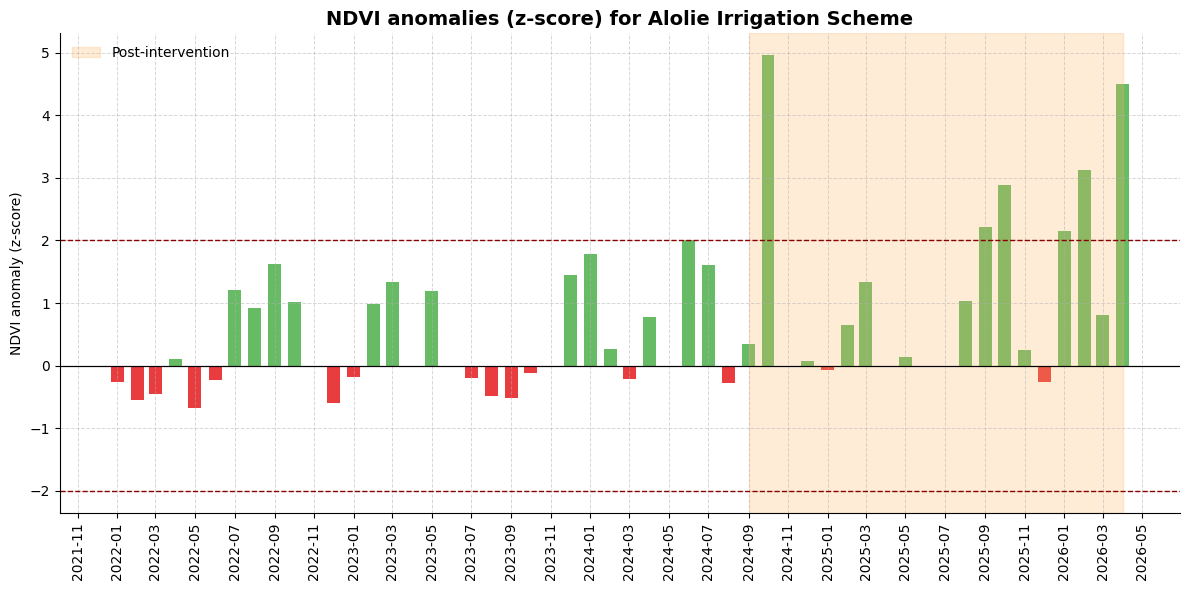

In [74]:
barplot_ndvi_zscore(df_aoi, intervention_date=cfg.intervention_date, title="NDVI anomalies (z-score) for Alolie Irrigation Scheme")

In [86]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from dataclasses import dataclass, field
from typing import Literal, Union, Dict, Optional
from pathlib import Path


ee.Authenticate()
ee.Initialize(project="paolomizu")


# ══════════════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class AnalysisConfig:
    """
    Central configuration for an NDVI analysis run.
    Separating config from logic makes the functions reusable across
    regions and time periods without touching function signatures.

    Args:
        study_start:        Start of study period (ISO string).
        study_end:          End of study period (ISO string).
        baseline_start:     Start of baseline period (ISO string).
        baseline_end:       End of baseline period (ISO string).
        intervention_date:  Date of intervention (ISO string). Used for
                            annotations on charts, not for filtering.
        cloud_threshold:    Max CLOUDY_PIXEL_PERCENTAGE for S2 filtering.
        scale:              Spatial scale in metres for reduceRegion.
        reducer:            "median" (default) or "mean" for compositing.
        seasons:            Dict of season definitions. Each entry:
                            {"months": [int, ...], "label": str}
        ndvi_viz:           GEE visualisation params for NDVI layers.
        anomaly_viz:        GEE visualisation params for anomaly layers.
        zscore_viz:         GEE visualisation params for z-score layers.
        export_crs:         CRS for GeoTIFF export (default EPSG:4326).
        export_scale:       Scale in metres for GeoTIFF export.
    """

    study_start:       str = "2022-01-01"
    study_end:         str = "2026-04-30"
    baseline_start:    str = "2018-01-01"
    baseline_end:      str = "2023-12-31"
    intervention_date: str = "2024-10-01"
    cloud_threshold:   int = 20
    scale:             int = 20
    reducer:           Literal["median", "mean"] = "median"

    seasons: dict = field(default_factory=lambda: {
        "dry1": {"months": [1, 2],       "label": "Dry Season 1 (JF)"},
        "gu":   {"months": [3, 4, 5],    "label": "Gu (Long Rains, MAM)"},
        "dry2": {"months": [6, 7, 8, 9], "label": "Dry Season 2 (JJAS)"},
        "deyr": {"months": [10, 11, 12], "label": "Deyr (Short Rains, OND)"},
    })

    ndvi_viz: dict = field(default_factory=lambda: {
        "min": 0.0, "max": 0.8,
        "palette": ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"],
    })
    anomaly_viz: dict = field(default_factory=lambda: {
        "min": -0.3, "max": 0.3,
        "palette": ["#d73027", "#fc8d59", "#ffffbf", "#91cf60", "#1a9850"],
    })
    zscore_viz: dict = field(default_factory=lambda: {
        "min": -3, "max": 3,
        "palette": ["#d73027", "#ffffbf", "#1a9850"],
    })

    export_crs:   str = "EPSG:4326"
    export_scale: int = 10   # 10m for export — finer than analysis scale


# ══════════════════════════════════════════════════════════════════════════════
# Geometry helpers
# ══════════════════════════════════════════════════════════════════════════════

# Type alias — used throughout
GEEGeometry = Union[ee.Geometry, ee.Feature, ee.FeatureCollection]


def fc_from_geojson(path: Union[str, Path]) -> ee.FeatureCollection:
    """Load a local GeoJSON file as an ee.FeatureCollection."""
    with open(path, "r") as f:
        geojson = json.load(f)
    return ee.FeatureCollection(geojson)


def to_geometry(region: GEEGeometry) -> ee.Geometry:
    """
    Normalise any GEE region type to ee.Geometry.
    Needed because filterBounds, reduceRegion, etc. behave differently
    depending on whether they receive a Geometry, Feature, or FeatureCollection.
    """
    if isinstance(region, ee.FeatureCollection):
        return region.geometry()
    if isinstance(region, ee.Feature):
        return region.geometry()
    return region


# ══════════════════════════════════════════════════════════════════════════════
# Core collection builder
# ══════════════════════════════════════════════════════════════════════════════

def build_s2_ndvi_collection(
    geometry: GEEGeometry,
    start_date: str,
    end_date: str,
    cloud_threshold: int = 20,
) -> ee.ImageCollection:
    """
    Return a cloud-masked, NDVI-only Sentinel-2 SR collection.
    This is the single entry point for raw data — all other functions
    filter down from here rather than rebuilding.
    """

    def mask_clouds(image: ee.Image) -> ee.Image:
        qa          = image.select("QA60")
        scl         = image.select("SCL")
        cloud_mask  = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        shadow_mask = scl.neq(3)
        return (
            image
            .updateMask(cloud_mask.And(shadow_mask))
            .divide(10000)
            .copyProperties(image, ["system:time_start"])
        )

    def add_ndvi(image: ee.Image) -> ee.Image:
        return image.addBands(
            image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        )

    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(to_geometry(geometry))
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_clouds)
        .map(add_ndvi)
        .select("NDVI")
    )


# ══════════════════════════════════════════════════════════════════════════════
# Internal helpers
# ══════════════════════════════════════════════════════════════════════════════

def _get_reducer(reducer: Literal["median", "mean"]) -> ee.Reducer:
    return ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()



def _collection_to_dataframe(
    collection: ee.ImageCollection,
    geometry: GEEGeometry,
    scale: int,
    properties: list[str],
    zone_label: str,
    band_names: list[str] = ["NDVI"],
) -> pd.DataFrame:
    """
    Reduce an ImageCollection to a scalar-per-image DataFrame.

    Args:
        band_names: List of bands to extract from reduceRegion
                    (e.g. ["NDVI"] or ["NDVI_mean", "NDVI_stdDev"])
    """
    geom = to_geometry(geometry)

    def extract(image: ee.Image) -> ee.Feature:
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=scale,
            maxPixels=1e9,
        )

        props = {p: image.get(p) for p in properties}
        for band in band_names:
            props[band] = stats.get(band)

        props["zone"] = zone_label
        return ee.Feature(None, props)

    rows = ee.FeatureCollection(collection.map(extract)).getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in rows])


def _safe_composite(
    collection: ee.ImageCollection,
    reducer: ee.Reducer,
) -> ee.Image:
    """
    Reduce a collection to a composite, returning a fully masked image
    if the collection is empty. Prevents band-not-found errors downstream.
    """
    empty = ee.Image.constant(0).selfMask().rename("NDVI")
    return ee.Image(
        ee.Algorithms.If(
            collection.size().gt(0),
            collection.reduce(reducer).rename("NDVI"),
            empty,
        )
    )


# ══════════════════════════════════════════════════════════════════════════════
# Monthly composites
# ══════════════════════════════════════════════════════════════════════════════

def monthly_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute monthly NDVI composites over the study period.

    Builds the full S2 collection once, then filters per month — avoids
    redundant collection instantiation for every time step.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per month, 'NDVI' band
          "dataframe":  pd.DataFrame,        # columns: date, ndvi, n_images, zone
        }
    """
    cfg = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    # Build once, filter per month
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    start    = ee.Date(cfg.study_start)
    end      = ee.Date(cfg.study_end)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def composite_one_month(offset: ee.Number) -> ee.Image:
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = full_col.filterDate(month_start, month_end)

        return (
            _safe_composite(monthly, _reducer)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(composite_one_month))

    df = _collection_to_dataframe(
        monthly_col, geometry, cfg.scale,
        properties=["date_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.rename(columns={"date_label": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Seasonal composites
# ══════════════════════════════════════════════════════════════════════════════

def seasonal_ndvi(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-season NDVI composites for each year in the study period.

    Builds the full S2 collection once, then filters per season/year.

    Returns:
        {
          "collection": ee.ImageCollection,  # one image per (year, season)
          "dataframe":  pd.DataFrame,        # columns: year, season, season_label,
                                             #          ndvi, n_images, zone
        }
    """
    cfg      = config or AnalysisConfig()
    _reducer = _get_reducer(cfg.reducer)

    start_year = int(cfg.study_start[:4])
    end_year   = int(cfg.study_end[:4])

    # Build full collection once
    full_col = build_s2_ndvi_collection(
        geometry, cfg.study_start, cfg.study_end, cfg.cloud_threshold
    )

    images = []
    for year in range(start_year, end_year + 1):
        for season_key, season_info in cfg.seasons.items():
            months  = season_info["months"]
            s_start = ee.Date.fromYMD(year, months[0], 1)

            # Filter the already-built collection — no redundant S2 query
            seasonal = full_col.filter(
                ee.Filter.calendarRange(months[0], months[-1], "month")
            ).filterDate(
                f"{year}-{months[0]:02d}-01",
                f"{year}-{months[-1]:02d}-28",
            )

            image = (
                _safe_composite(seasonal, _reducer)
                .set("year",              year)
                .set("season",            season_key)
                .set("season_label",      season_info["label"])
                .set("system:time_start", s_start.millis())
                .set("n_images",          seasonal.size())
            )
            images.append(image)

    seasonal_col = ee.ImageCollection(images)

    df = _collection_to_dataframe(
        seasonal_col, geometry, cfg.scale,
        properties=["year", "season", "season_label", "n_images"],
        zone_label=zone_label,
        band_names=["NDVI"]
    )
    df = df.sort_values(["year", "season"]).reset_index(drop=True)

    return {"collection": seasonal_col, "dataframe": df}


# ══════════════════════════════════════════════════════════════════════════════
# Baseline
# ══════════════════════════════════════════════════════════════════════════════

def compute_monthly_baseline(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
) -> dict:
    """
    Compute per-calendar-month NDVI statistics over the baseline period.
    Builds the S2 collection once and filters per calendar month.

    Returns:
        {
          "dataframe":   pd.DataFrame,        # stats per calendar month
          "mean_images": ee.ImageCollection,  # one mean image per month
          "std_images":  ee.ImageCollection,  # one std image per month
        }
    """
    cfg = config or AnalysisConfig()

    collection = build_s2_ndvi_collection(
        geometry, cfg.baseline_start, cfg.baseline_end, cfg.cloud_threshold
    )
    months = ee.List.sequence(1, 12)

    def stats_for_month(month: ee.Number) -> ee.Image:
        month   = ee.Number(month)
        monthly = collection.filter(ee.Filter.calendarRange(month, month, "month"))
        empty   = ee.Image.constant(0).selfMask().rename("NDVI")

        stats_image = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_images", monthly.size())
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    mean_images = baseline_col.map(
        lambda img: img.select("NDVI_mean")
                      .rename("NDVI")
                      .set("month", img.get("month"))
    )
    std_images = baseline_col.map(
        lambda img: img.select("NDVI_stdDev")
                      .rename("NDVI_std")
                      .set("month", img.get("month"))
    )

    df = _collection_to_dataframe(
        baseline_col, geometry, cfg.scale,
        properties=["month", "n_images"],
        zone_label=zone_label,
        band_names=[
                "NDVI_mean",
                "NDVI_median",
                "NDVI_stdDev",
                "NDVI_min",
                "NDVI_max",
                "NDVI_count",
            ],
    )
    # Rename stat bands to match expected column names
    df = df.rename(columns={
        "NDVI_mean":   "mean",
        "NDVI_median": "median",
        "NDVI_stdDev": "std",
        "NDVI_min":    "min",
        "NDVI_max":    "max",
        "NDVI_count":  "count",
    })
    df["month"] = df["month"].astype(int)

    return {
        "dataframe":   df.sort_values("month").reset_index(drop=True),
        "mean_images": mean_images,
        "std_images":  std_images,
    }


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly images
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomaly_images(
    study_collection: ee.ImageCollection,
    baseline_mean_images: ee.ImageCollection,
    baseline_std_images: ee.ImageCollection,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    config: AnalysisConfig = None,
) -> ee.ImageCollection:
    """
    Add anomaly_abs and z_score bands to every image in the study collection.

    Monthly:  matches baseline on 'month' property.
    Seasonal: averages baseline images across the months in each season.

    Returns ee.ImageCollection with bands: NDVI, anomaly_abs, z_score.
    """
    cfg = config or AnalysisConfig()

    # Build a server-side season→months dictionary from config
    # so seasons are not hardcoded here
    season_months_dict = ee.Dictionary({
        k: v["months"] for k, v in cfg.seasons.items()
    })

    def add_anomaly(image: ee.Image) -> ee.Image:
        if temporal_resolution == "monthly":
            month = image.get("month")
            b_mean = ee.Image(
                baseline_mean_images.filter(ee.Filter.eq("month", month)).first()
            )
            b_std = ee.Image(
                baseline_std_images.filter(ee.Filter.eq("month", month)).first()
            )
        else:
            month_list = ee.List(season_months_dict.get(image.get("season")))
            b_mean = baseline_mean_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()
            b_std = baseline_std_images.filter(
                ee.Filter.inList("month", month_list)
            ).mean()

        anomaly_abs = image.select("NDVI").subtract(b_mean).rename("anomaly_abs")
        z_score     = anomaly_abs.divide(b_std).rename("z_score")

        return (
            image
            .addBands(anomaly_abs)
            .addBands(z_score)
            .copyProperties(image, [
                "year", "month", "season", "season_label",
                "system:time_start", "date_label", "n_images",
            ])
        )

    return study_collection.map(add_anomaly)


# ══════════════════════════════════════════════════════════════════════════════
# Anomaly DataFrame
# ══════════════════════════════════════════════════════════════════════════════

def compute_anomalies(
    study_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    config: AnalysisConfig = None,
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
) -> pd.DataFrame:
    """
    Join study-period NDVI with baseline stats and compute anomaly columns.
    Works for both monthly (joins on 'month') and seasonal (aggregates
    baseline months per season then joins on 'season') resolutions.

    Adds columns: anomaly_abs, anomaly_pct, z_score.
    """
    cfg = config or AnalysisConfig()
    df  = study_df.copy()

    if temporal_resolution == "monthly":
        df["month"] = df["date"].dt.month
        join_key    = "month"
        bl          = baseline_df

    else:
        season_to_months = {k: v["months"] for k, v in cfg.seasons.items()}
        rows = []
        for season_key, months in season_to_months.items():
            subset = baseline_df[baseline_df["month"].isin(months)]
            for zone, grp in subset.groupby("zone"):
                rows.append({
                    "season": season_key,
                    "zone":   zone,
                    "mean":   grp["mean"].mean(),
                    "median": grp["median"].mean(),
                    "std":    grp["std"].mean(),
                    "min":    grp["min"].min(),
                    "max":    grp["max"].max(),
                })
        bl       = pd.DataFrame(rows)
        join_key = "season"

    df = df.merge(
        bl[[join_key, "mean", "median", "std", "min", "max", "zone"]],
        on=[join_key, "zone"],
        how="left",
    )
    df["anomaly_abs"] = df["NDVI"] - df["mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["std"]

    if temporal_resolution == "monthly" and "month" not in study_df.columns:
        df = df.drop(columns="month")

    return df

# ══════════════════════════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════════════════════════
def barplot_ndvi_zscore(
    df: pd.DataFrame,
    intervention_date: Optional[str] = None,
    title: str = "NDVI Anomalies (Z-score)",
    figsize: tuple = (12, 6),
    month_interval: int = 2
):

    df = df.sort_values("date")
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        df["date"],
        df["z_score"],
        color=df["z_score"].apply(
            lambda x: "#4daf4a" if x > 0 else "#e41a1c"
        ),
        width=20,  # days, good for monthly data
        alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title("NDVI anomalies")


    # Shade intervention period
    if intervention_date is not None:
        intervention_date = pd.to_datetime(intervention_date)
        ax.axvspan(
            intervention_date,
            df["date"].max(),
            color="#fdb462",
            alpha=0.25,
            label="Post‑intervention"
        )

    # Control x-axis tick
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=month_interval)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )
    
    # Subtle grid
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)


    # Thresholds
    ax.axhline(2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(-2, color="#890000", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel("NDVI anomaly (z-score)")
    ax.set_title(title, fontsize=14, weight="bold")

    
    # Remove top/right spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Improve date label readability
    ax.tick_params(axis="x", rotation=90)

    # Optional legend (only if intervention is shown)
    if intervention_date is not None:
        ax.legend(frameon=False, loc="upper left")


    fig.tight_layout()
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# Map display + GeoTIFF export
# ══════════════════════════════════════════════════════════════════════════════

def _get_image_from_collection(
    collection: ee.ImageCollection,
    date_label: str,
    temporal_resolution: Literal["monthly", "seasonal"],
) -> ee.Image:
    """
    Filter a collection to a single image by date_label.

    date_label format:
        monthly:  "YYYY-MM"      e.g. "2025-01"
        seasonal: "YYYY-season"  e.g. "2025-dry1"
    """
    year_str, period_str = date_label.split("-", maxsplit=1)
    year = int(year_str)

    if temporal_resolution == "monthly":
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",  year))
            .filter(ee.Filter.eq("month", int(period_str)))
            .first()
        )
    else:
        return ee.Image(
            collection
            .filter(ee.Filter.eq("year",   year))
            .filter(ee.Filter.eq("season", period_str))
            .first()
        )


def add_ndvi_layers_to_map(
    m: geemap.Map,
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    zoom: int = 13,
) -> None:
    """
    Add NDVI, anomaly and z-score layers to a geemap Map for a given period.

    Args:
        m:                    geemap.Map instance.
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             AOI to centre the map on.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to layer names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Subset of ["NDVI", "anomaly_abs", "z_score"] to add.
                              Defaults to all three.
        zoom:                 Map zoom level.
    """
    cfg    = config or AnalysisConfig()
    bands  = bands or ["NDVI", "anomaly_abs", "z_score"]
    prefix = f"{label_prefix} " if label_prefix else ""
    image  = _get_image_from_collection(collection, date_label, temporal_resolution)

    band_configs = {
        "NDVI":        (cfg.ndvi_viz,    f"{prefix}NDVI {date_label}"),
        "anomaly_abs": (cfg.anomaly_viz, f"{prefix}Anomaly {date_label}"),
        "z_score":     (cfg.zscore_viz,  f"{prefix}Z-score {date_label}"),
    }

    for band in bands:
        if band in band_configs:
            viz, name = band_configs[band]
            m.addLayer(image.select(band), viz, name)

    m.centerObject(to_geometry(geometry), zoom=zoom)


def export_ndvi_to_tiff(
    collection: ee.ImageCollection,
    date_label: str,
    geometry: GEEGeometry,
    output_dir: Union[str, Path],
    config: AnalysisConfig = None,
    label_prefix: str = "",
    temporal_resolution: Literal["monthly", "seasonal"] = "monthly",
    bands: list[str] = None,
    to_drive: bool = False,
    drive_folder: str = "GEE_exports",
) -> None:
    """
    Export NDVI/anomaly bands as GeoTIFFs — either locally via geemap
    or to Google Drive via the GEE Tasks API.

    Local export uses geemap.ee_export_image() which downloads directly
    to disk. Drive export submits a GEE task (non-blocking).

    Args:
        collection:           Output of compute_anomaly_images().
        date_label:           "YYYY-MM" or "YYYY-seasonkey".
        geometry:             Export region.
        output_dir:           Local directory for GeoTIFF files.
        config:               AnalysisConfig (uses defaults if None).
        label_prefix:         Prepended to file names.
        temporal_resolution:  "monthly" or "seasonal".
        bands:                Bands to export. Defaults to all three.
        to_drive:             If True, export to Google Drive instead of locally.
        drive_folder:         Google Drive folder name (used when to_drive=True).
    """
    cfg        = config or AnalysisConfig()
    bands      = bands or ["NDVI", "anomaly_abs", "z_score"]
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image  = _get_image_from_collection(collection, date_label, temporal_resolution)
    region = to_geometry(geometry)
    prefix = f"{label_prefix}_" if label_prefix else ""

    for band in bands:
        filename = f"{prefix}{band}_{date_label}"
        img_band = image.select(band)

        if to_drive:
            task = ee.batch.Export.image.toDrive(
                image=img_band,
                description=filename[:100],   # GEE task name limit
                folder=drive_folder,
                fileNamePrefix=filename,
                region=region,
                scale=cfg.export_scale,
                crs=cfg.export_crs,
                maxPixels=1e13,
                fileFormat="GeoTIFF",
            )
            task.start()
            print(f"[Drive] Task submitted: {filename}.tif")

        else:
            out_path = output_dir / f"{filename}.tif"
            geemap.ee_export_image(
                img_band,
                filename=str(out_path),
                scale=cfg.export_scale,
                region=region,
                crs=cfg.export_crs,
                file_per_band=False,
            )
            print(f"[Local] Saved: {out_path}")

# ══════════════════════════════════════════════════════════════════════════════
# CHIRPS precipitation
# ══════════════════════════════════════════════════════════════════════════════

def build_chirps_monthly(
    geometry: GEEGeometry,
    start_date: str,
    end_date: str,
    scale: int = 5500,
) -> dict:
    """
    Aggregate CHIRPS pentad data to monthly precipitation totals.

    Sums pentad images within each calendar month — correct for
    accumulation data (never use mean for rainfall totals).

    Returns:
        {
          "collection": ee.ImageCollection,  # monthly, band: 'precipitation'
          "dataframe":  pd.DataFrame,        # columns: date, precipitation,
                                             #          n_images, zone
        }

    Note:
        scale=5500 matches CHIRPS native ~5.5km resolution.
        Passing a finer scale just triggers unnecessary resampling.
    """
    geom = to_geometry(geometry)

    chirps = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterBounds(geom)
        .filterDate(start_date, end_date)
        .select("precipitation")
    )

    start    = ee.Date(start_date)
    end      = ee.Date(end_date)
    n_months = end.difference(start, "month").round()
    offsets  = ee.List.sequence(0, n_months.subtract(1))

    def sum_one_month(offset: ee.Number) -> ee.Image:
        month_start = start.advance(offset, "month")
        month_end   = month_start.advance(1, "month")
        monthly     = chirps.filterDate(month_start, month_end)

        # Empty guard — return masked image if no pentads found
        empty = ee.Image.constant(0).selfMask().rename("precipitation")
        composite = ee.Algorithms.If(
            monthly.size().gt(0),
            monthly.sum().rename("precipitation"),
            empty,
        )

        return (
            ee.Image(composite)
            .set("year",              month_start.get("year"))
            .set("month",             month_start.get("month"))
            .set("system:time_start", month_start.millis())
            .set("date_label",        month_start.format("YYYY-MM"))
            .set("n_images",          monthly.size())
        )

    monthly_col = ee.ImageCollection(offsets.map(sum_one_month))

    df = _collection_to_dataframe(
        monthly_col, geometry, scale,
        properties=["date_label", "n_images"],
        zone_label="chirps",          # fixed — CHIRPS is not zone-specific
        band_names=["precipitation"],
    )
    df = df.rename(columns={"date_label": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return {"collection": monthly_col, "dataframe": df}


def compute_chirps_baseline(
    geometry: GEEGeometry,
    baseline_start: str,
    baseline_end: str,
    scale: int = 5500,
) -> pd.DataFrame:
    """
    Compute baseline monthly precipitation statistics.

    Correctly aggregates in two steps:
        1. Sum pentads → monthly total per year
        2. Compute stats (mean, std, etc.) across those annual totals
           for each calendar month

    This gives the distribution of true monthly totals across years,
    not the distribution of individual pentad values.
    """
    geom = to_geometry(geometry)

    chirps = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterBounds(geom)
        .filterDate(baseline_start, baseline_end)
        .select("precipitation")
    )

    start_year = int(baseline_start[:4])
    end_year   = int(baseline_end[:4])
    years      = list(range(start_year, end_year + 1))

    # Step 1 — one monthly total image per (year, month)
    monthly_images = []
    for year in years:
        for month in range(1, 13):
            m_start = f"{year}-{month:02d}-01"
            m_end   = ee.Date(m_start).advance(1, "month").format("YYYY-MM-dd")

            monthly_total = (
                chirps
                .filterDate(m_start, m_end.getInfo())
                .sum()
                .rename("precipitation")
                .set("year",  year)
                .set("month", month)
            )
            monthly_images.append(monthly_total)

    monthly_col = ee.ImageCollection(monthly_images)

    # Step 2 — stats across years for each calendar month
    months = ee.List.sequence(1, 12)

    def stats_for_month(month: ee.Number) -> ee.Image:
        month      = ee.Number(month)
        same_month = monthly_col.filter(ee.Filter.eq("month", month))
        empty      = ee.Image.constant(0).selfMask().rename("precipitation")

        stats_image = ee.Algorithms.If(
            same_month.size().gt(0),
            same_month.reduce(
                ee.Reducer.mean()
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.min(),    sharedInputs=True)
                .combine(ee.Reducer.max(),    sharedInputs=True)
                .combine(ee.Reducer.count(),  sharedInputs=True)
            ),
            empty,
        )

        return (
            ee.Image(stats_image)
            .set("month",    month)
            .set("n_years",  same_month.size())  # how many years went into the stats
        )

    baseline_col = ee.ImageCollection(months.map(stats_for_month))

    df = _collection_to_dataframe(
        baseline_col, geometry, scale,
        properties=["month", "n_years"],
        zone_label="chirps",
        band_names=[
            "precipitation_mean",
            "precipitation_stdDev",
            "precipitation_median",
            "precipitation_min",
            "precipitation_max",
        ],
    )

    df = df.rename(columns={
        "precipitation_mean":   "precip_mean",
        "precipitation_stdDev": "precip_std",
        "precipitation_median": "precip_median",
        "precipitation_min":    "precip_min",
        "precipitation_max":    "precip_max",
    })
    df["month"] = df["month"].astype(int)

    return df.sort_values("month").reset_index(drop=True)


def compute_precip_anomalies(
    chirps_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Join monthly precipitation with baseline stats and compute anomalies.

    Adds columns:
        anomaly_abs  — precipitation minus baseline mean (mm)
        anomaly_pct  — anomaly as % of baseline mean
        z_score      — normalised anomaly
    """
    df = chirps_df.copy()
    df["month"] = df["date"].dt.month

    df = df.merge(
        baseline_df[["month", "precip_mean", "precip_std",
                     "precip_median", "precip_min", "precip_max"]],
        on="month",
        how="left",
    )

    df["anomaly_abs"] = df["precipitation"] - df["precip_mean"]
    df["anomaly_pct"] = (df["anomaly_abs"] / df["precip_mean"]) * 100
    df["z_score"]     = df["anomaly_abs"] / df["precip_std"]

    return df.drop(columns="month")

def barplot_precip_zscore(
    precip_df: pd.DataFrame,
    intervention_date: str = None,
    title: str = "Precipitation Anomalies (Z-score)",
    figsize: tuple = (12, 6),
    month_interval: int = 2,
) -> plt.Figure:
    """
    Bar chart of monthly precipitation z-score anomalies.
    Mirrors barplot_ndvi_zscore for visual consistency.
    """
    df  = precip_df.sort_values("date")
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        df["date"],
        df["z_score"],
        color=df["z_score"].apply(lambda x: "#2166ac" if x > 0 else "#d6604d"),
        width=20,
        alpha=0.85,
    )

    ax.axhline(0,  color="black",   linewidth=0.8)
    ax.axhline(2,  color="#08306b", linestyle="--", linewidth=1)
    ax.axhline(-2, color="#08306b", linestyle="--", linewidth=1)

    if intervention_date is not None:
        ax.axvspan(
            pd.to_datetime(intervention_date),
            df["date"].max(),
            color="#fdb462", alpha=0.25, label="Post-intervention",
        )

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=month_interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=90)
    ax.set_ylabel("Precipitation anomaly (z-score)")
    ax.set_title(title, fontsize=14, weight="bold")
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if intervention_date is not None:
        ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    return fig


def barplot_ndvi_precip_combined(
    ndvi_df: pd.DataFrame,
    precip_df: pd.DataFrame,
    intervention_date: str = None,
    title: str = "NDVI vs Precipitation Anomalies (Z-score)",
    figsize: tuple = (14, 6),
    month_interval: int = 2,
) -> plt.Figure:

    ndvi_df   = ndvi_df.sort_values("date")
    precip_df = precip_df.sort_values("date")

    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    bar_width = 15

    ax2.bar(
        precip_df["date"],
        precip_df["z_score"],
        color=precip_df["z_score"].apply(lambda x: "#2166ac" if x > 0 else "#d6604d"),
        width=bar_width,
        alpha=0.35,
        label="Precipitation z-score",
    )
    ax2.set_ylabel("Precipitation anomaly (z-score)", color="#2166ac")
    ax2.tick_params(axis="y", labelcolor="#2166ac")
    ax2.spines["top"].set_visible(False)

    ax1.bar(
        ndvi_df["date"],
        ndvi_df["z_score"],
        color=ndvi_df["z_score"].apply(lambda x: "#4daf4a" if x > 0 else "#e41a1c"),
        width=bar_width,
        alpha=0.85,
        label="NDVI z-score",
    )
    ax1.axhline(0,  color="black",   linewidth=0.8)
    ax1.axhline(2,  color="#890000", linestyle="--", linewidth=1)
    ax1.axhline(-2, color="#890000", linestyle="--", linewidth=1)
    ax1.set_ylabel("NDVI anomaly (z-score)")
    ax1.spines["top"].set_visible(False)

    # ── Align zeros — compute symmetric limits for each axis independently,
    #    then scale both so their zero lines sit at the same relative position
    ndvi_abs_max   = ndvi_df["z_score"].abs().max()
    precip_abs_max = precip_df["z_score"].abs().max()

    # Add 10% headroom so bars don't touch the axis edge
    ndvi_lim   = ndvi_abs_max   * 1.1
    precip_lim = precip_abs_max * 1.1

    ax1.set_ylim(-ndvi_lim,   ndvi_lim)
    ax2.set_ylim(-precip_lim, precip_lim)

    if intervention_date is not None:
        ax1.axvspan(
            pd.to_datetime(intervention_date),
            ndvi_df["date"].max(),
            color="#fdb462", alpha=0.2, label="Post-intervention",
        )

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=month_interval))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax1.tick_params(axis="x", rotation=90)
    ax1.set_title(title, fontsize=14, weight="bold")
    ax1.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
    ax1.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.4)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc="upper left")

    fig.tight_layout()
    return fig

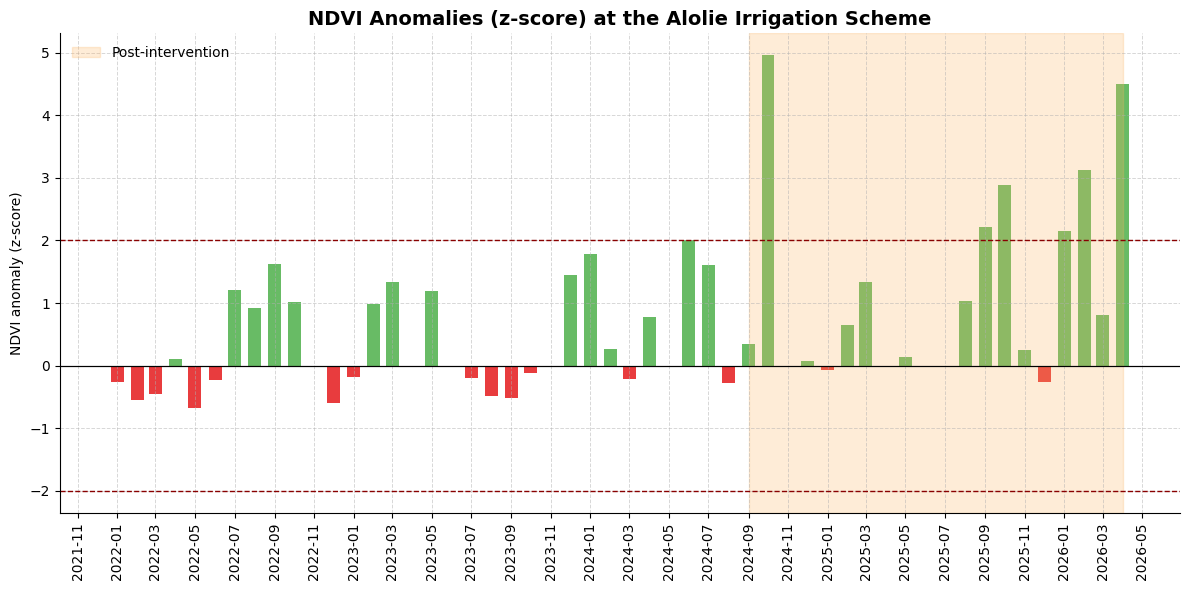

In [80]:
### ---------- ###

# ── Config — swap this out per project, nothing else changes
cfg = AnalysisConfig(
    study_start="2022-01-01",
    study_end="2026-04-30",
    baseline_start="2018-01-01",
    baseline_end="2023-12-31",
    intervention_date="2024-09-01",
)

# ── Geometries
aoi     = fc_from_geojson("../geojson/alenolie_irrigation_scheme.geojson")
control = fc_from_geojson("../geojson/control_field.geojson")
buffer  = fc_from_geojson("../geojson/buffer.geojson")

# Define the full Hanaano region box
hanaano_box = ee.Geometry.Polygon([
    [41.91,4.319],
    [41.96,4.319],
    [41.96,4.352],
    [41.91,4.352]
])

# # ── Run
# baseline      = compute_monthly_baseline(aoi, config=cfg, zone_label="aoi")
# result_seas   = seasonal_ndvi(aoi, config=cfg, zone_label="aoi")
# anomaly_seas  = compute_anomaly_images(
#     result_seas["collection"],
#     baseline["mean_images"],
#     baseline["std_images"],
#     temporal_resolution="seasonal",
#     config=cfg,
# )

# # ── Export — local
# export_ndvi_to_tiff(
#     anomaly_seas, "2023-dry1", hanaano_box,
#     output_dir="../outputs/tiff",
#     config=cfg,
#     label_prefix="Hanaano",
#     temporal_resolution="seasonal",
#     bands=["NDVI", "anomaly_abs"],
# )

# Data analysis and plotting
def data_analysis(
    geometry: GEEGeometry,
    config: AnalysisConfig = None,
    zone_label: str = "zone",
    temporal_resolution: Literal['monthly', 'seasonal'] = "monthly"
):
    
    baseline = compute_monthly_baseline(
        geometry=geometry,
        config=config,
        zone_label=zone_label
    )
    monthly = monthly_ndvi(
        geometry=geometry,
        config=config,
        zone_label=zone_label
    )
    df = compute_anomalies(
        study_df=monthly["dataframe"],
        baseline_df=baseline["dataframe"],
        config=config,
        temporal_resolution=temporal_resolution
    )
    return df

df = data_analysis(geometry=aoi, config=cfg, zone_label="Alolie Irrigation Scheme", temporal_resolution="monthly")
fig = barplot_ndvi_zscore(df=df, intervention_date=cfg.intervention_date, title=f"NDVI Anomalies (z-score) at the {df.zone.unique().item()}")
fig.show()

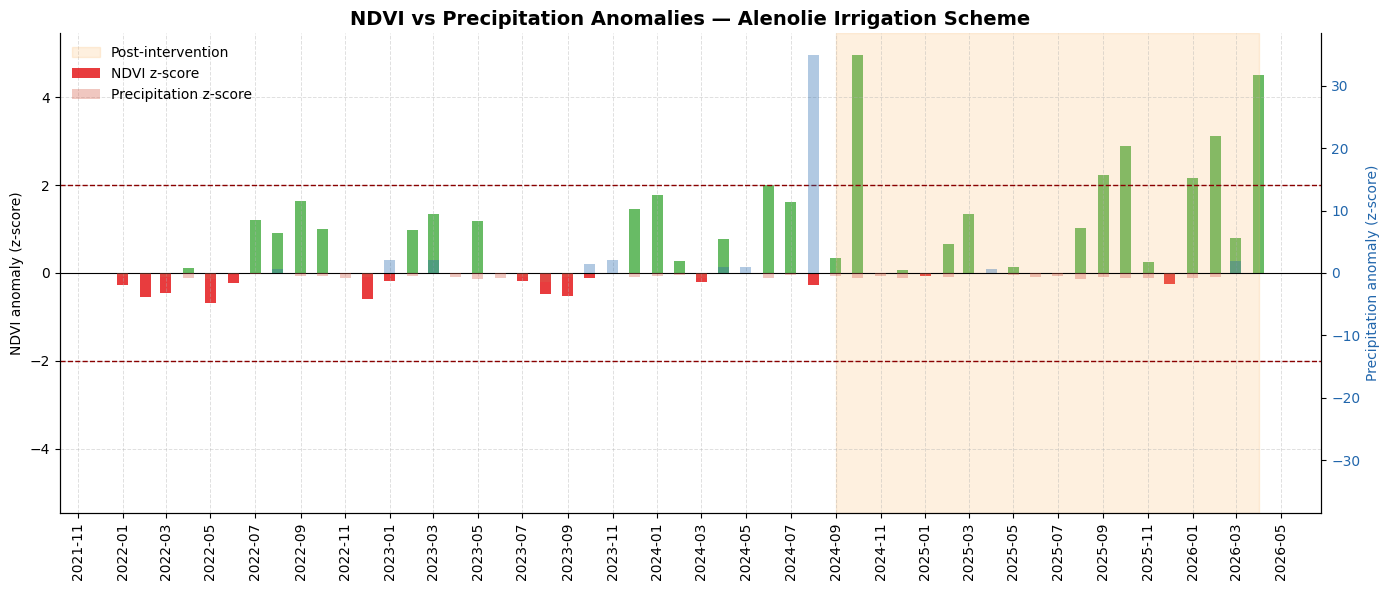

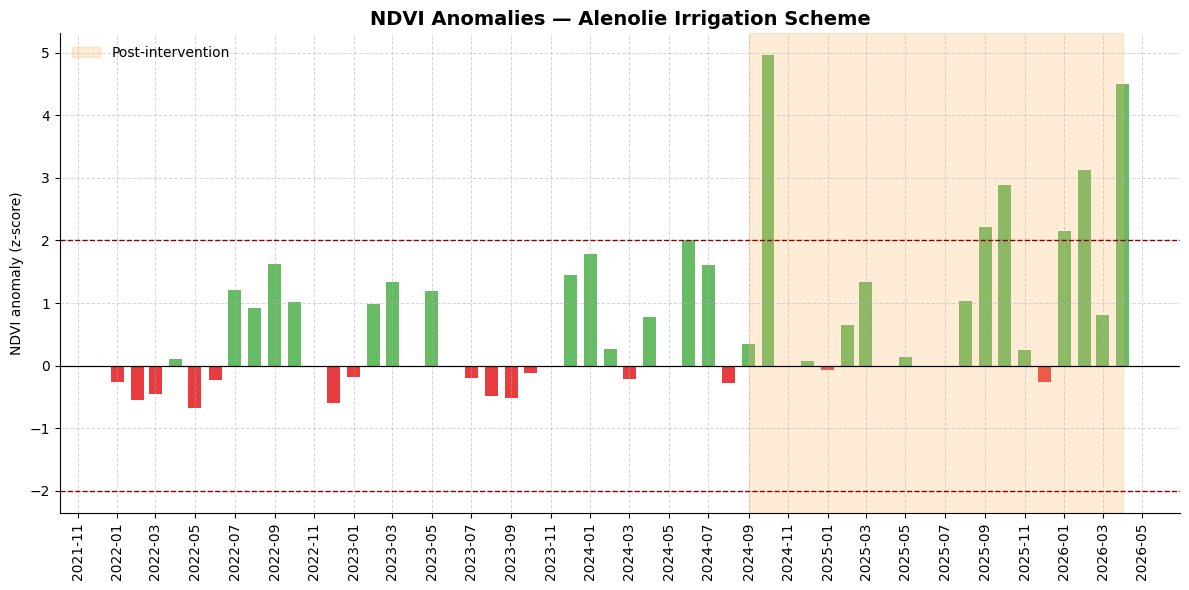

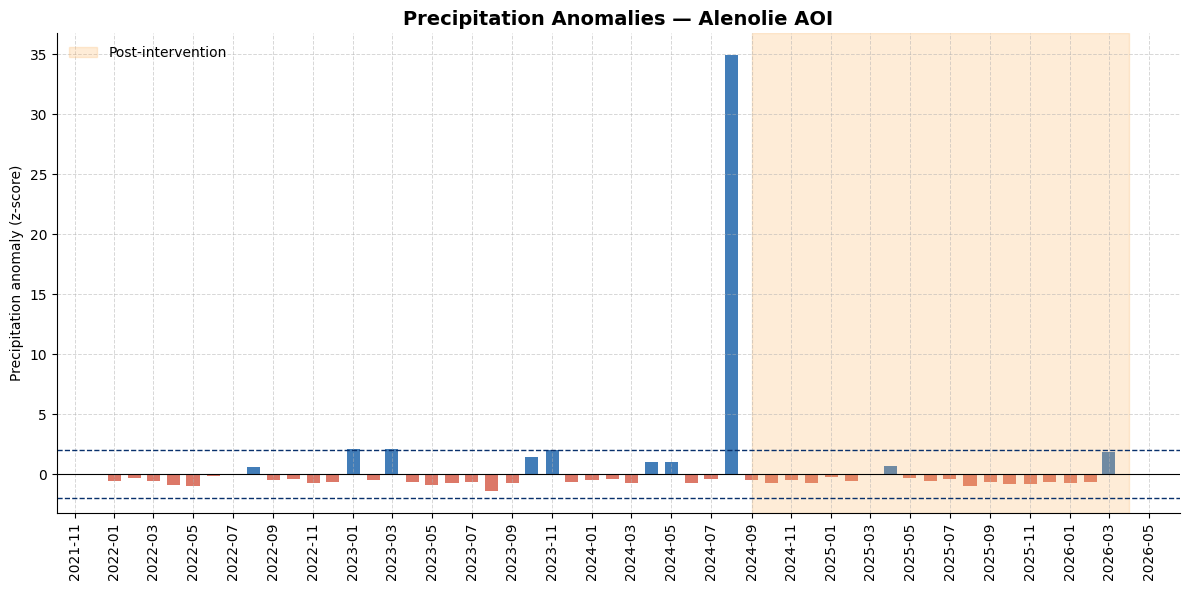

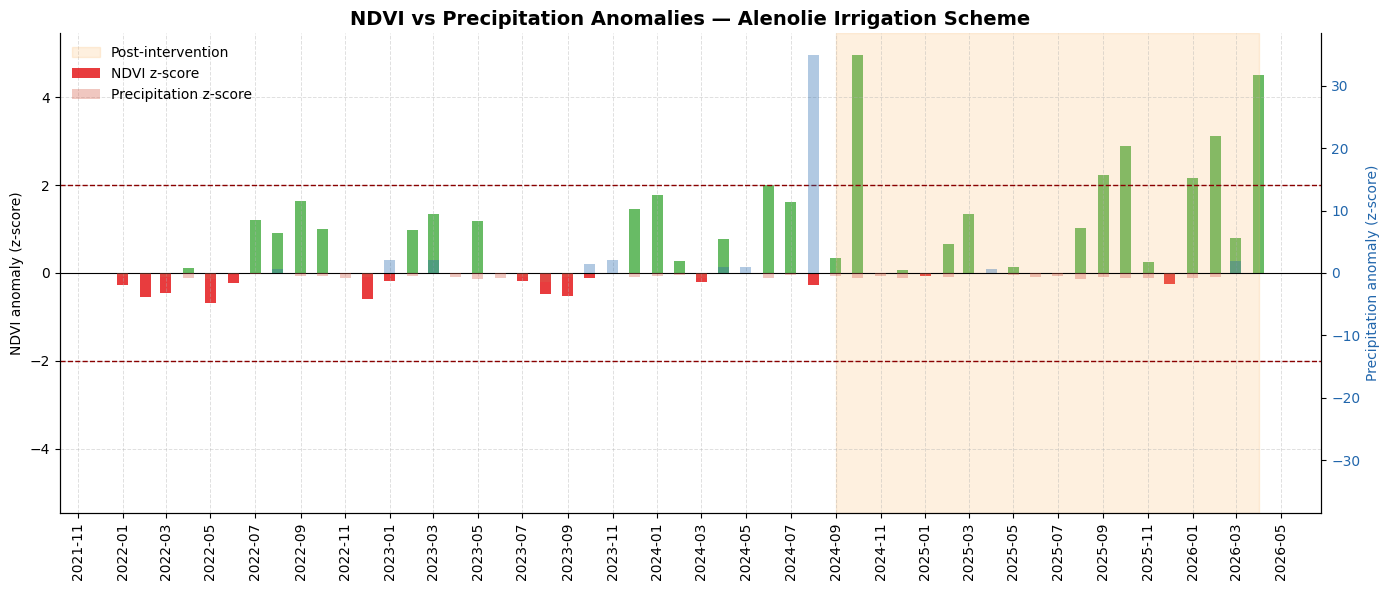

In [ ]:
# ── NDVI time series + baseline
ndvi_result = monthly_ndvi(aoi, cfg, "aoi")
ndvi_baseline = compute_monthly_baseline(aoi, cfg, "aoi")
ndvi_df = compute_anomalies(
        study_df=ndvi_result["dataframe"],
        baseline_df=ndvi_baseline["dataframe"],
        config=cfg,
        temporal_resolution="monthly"
    )

# ── CHIRPS time series + baseline
chirps_result  = build_chirps_monthly(hanaano_box, cfg.study_start, cfg.study_end)
chirps_baseline = compute_chirps_baseline(hanaano_box, cfg.baseline_start, cfg.baseline_end)
precip_df      = compute_precip_anomalies(chirps_result["dataframe"], chirps_baseline)

# ── Individual plots
barplot_ndvi_zscore(ndvi_df, intervention_date=cfg.intervention_date,
                    title="NDVI Anomalies — Alenolie Irrigation Scheme")

barplot_precip_zscore(precip_df, intervention_date=cfg.intervention_date,
                      title="Precipitation Anomalies — Alenolie AOI")

# ── Combined — the key diagnostic
barplot_ndvi_precip_combined(
    ndvi_df=ndvi_df,
    precip_df=precip_df,
    intervention_date=cfg.intervention_date,
    title="NDVI vs Precipitation Anomalies — Alenolie Irrigation Scheme",
)